# ***Assignment 3: Experimentation and Expansion of Previous Reproduction of Enhanced Credit Risk Prediction Using Deep Learning and SMOTE-ENN Resampling***

## ***Section 1: Title and Research Aim***

We extend the reproduced study, *Enhanced credit risk prediction using deep learning and SMOTE-ENN resampling*, by adding a third benchmark dataset and by comparing data-level and loss-level strategies for handling class imbalance in credit-risk prediction. Our notebook is written as a single reproducible research artifact so that the full workflow, from data loading through statistical analysis, can be executed without manual metric transcription.

**Research question.** Does SMOTE-ENN consistently improve deep learning credit-risk prediction across datasets, or do loss-based imbalance-handling methods generalize better by preserving the original data distribution?

**Hypotheses.**
- Loss-based imbalance handling, especially Weighted Binary Cross Entropy and Focal Loss, will provide more stable generalization than SMOTE-ENN because these methods do not synthetically alter the training distribution.
- Any gains observed under SMOTE-ENN will be dataset-dependent rather than universally reliable across the Australian, German, and UCI Default Credit Card benchmarks.

**Contribution statement.**
- We reproduce the paper-aligned MLP, LSTM, and GRU settings.
- We add the UCI Default of Credit Card Clients dataset as a larger external benchmark.
- We compare four experimental conditions: baseline BCE, SMOTE-ENN with BCE, Weighted BCE, and Focal Loss.
- We produce report-ready tables, statistical tests, confusion matrices, SHAP analyses, and exported artifacts from one source of truth.

**Datasets and methods summary.**
- Datasets: Australian Credit Approval, German Credit (numeric), UCI Default of Credit Card Clients.
- Models: MLP, LSTM, GRU.
- Imbalance conditions: baseline, SMOTE-ENN, Weighted BCE, Focal Loss.
- Evaluation: stratified cross-validation with paper metrics and imbalance-aware extensions.


## ***Section 2: Imports and Environment Setup***

We begin by ensuring that the notebook can run in Kaggle or a local environment with minimal manual intervention. The installation cell checks only the packages that are essential for this assignment and installs them only if they are missing. This keeps the notebook portable while avoiding unnecessary version churn in environments that are already configured correctly.


In [1]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "numpy": "numpy",
    "pandas": "pandas",
    "scikit-learn": "sklearn",
    "imbalanced-learn": "imblearn",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "shap": "shap",
    "torch": "torch",
    "tqdm": "tqdm",
    "openpyxl": "openpyxl",
    "xlrd": "xlrd",
}

missing_packages = [
    package_name
    for package_name, import_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
else:
    print("All required packages are already installed.")


All required packages are already installed.


The next cell imports the scientific computing, deep learning, visualization, explainability, and statistical testing libraries used throughout the notebook. We also define plotting defaults at import time so that all figures share a consistent visual standard suitable for academic reporting.


In [2]:
import copy
import gc
import json
import logging
import math
import os
import platform
import random
import shutil
import sys
import threading
import time
import warnings
from functools import lru_cache
from collections import defaultdict
from contextlib import nullcontext
from datetime import datetime
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shap
import torch
import torch.nn as nn
import torch.nn.functional as F
from imblearn.combine import SMOTEENN
from IPython.display import Markdown, display
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 7)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 13
plt.rcParams["legend.fontsize"] = 11
plt.rcParams["savefig.bbox"] = "tight"


## ***Section 3: Reproducibility Configuration***

Reproducibility in GPU deep learning is never absolute. Random initialization, batch ordering, CUDA kernels, and parallel execution can all introduce instability if they are not explicitly controlled. In this notebook we therefore centralize the experimental configuration, seed all relevant libraries, enable deterministic behavior where practical, and print the runtime environment before running any experiments.

The next cell defines a single `CONFIG` dictionary, detects whether the notebook is running on Kaggle, configures output directories, sets deterministic seeds, and prints an environment summary. We also explain the remaining nondeterministic sources: mixed precision arithmetic, certain cuDNN kernels, and hardware-level scheduling differences may still induce small run-to-run variation even under careful control.


In [3]:
def find_assignment3_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if candidate.name == "Assignment-3" and (candidate / "dataset").exists():
            return candidate
        if (candidate / "Assignment-3" / "dataset").exists():
            return candidate / "Assignment-3"
    return Path.cwd()


ASSIGNMENT3_ROOT = find_assignment3_root().resolve()
IS_KAGGLE = Path("/kaggle").exists()
ACTIVE_OUTPUT_ROOT = Path("/kaggle/working/assignment3_outputs") if IS_KAGGLE else ASSIGNMENT3_ROOT / "results"
ACTIVE_DATASET_ROOT = Path("/kaggle/input") if IS_KAGGLE else ASSIGNMENT3_ROOT / "dataset"

CONFIG: dict[str, Any] = {
    "seed": 42,
    "quick_run": False,
    "quick_run_folds": 3,
    "quick_run_epochs": 6,
    "quick_run_shap_background_size": 32,
    "quick_run_shap_explain_size": 24,
    "full_folds": 10,
    "full_epochs": 35,
    "early_stopping_patience": 5,
    "early_stopping_min_delta": 1e-4,
    "mixed_precision": True,
    "use_dataparallel": True,
    "parallel_experiments": False,
    "max_parallel_workers": 2,
    "default_threshold": 0.5,
    "shap_background_size": 64,
    "shap_explain_size": 64,
    "kernel_shap_nsamples": 40,
    "num_workers": min(4, os.cpu_count() or 1),
    "pin_memory": torch.cuda.is_available(),
    "persistent_workers": torch.cuda.is_available(),
    "prefetch_factor": 2,
    "eval_batch_multiplier": 4,
    "cache_preprocessed_folds": True,
    "save_non_mlp_checkpoints": False,
    "paths": {
        "assignment_root": str(ASSIGNMENT3_ROOT),
        "dataset_root": str(ACTIVE_DATASET_ROOT),
        "output_root": str(ACTIVE_OUTPUT_ROOT),
    },
    "datasets": ["australian", "german", "default_credit"],
    "models": ["mlp", "lstm", "gru"],
    "conditions": ["baseline", "smoteenn", "weighted_bce", "focal_loss"],
    "model_hyperparameters": {
        "mlp": {
            "learning_rate": 1e-3,
            "batch_size": 32,
            "hidden_units": 128,
            "dropout": 0.3,
            "optimizer": "adam",
        },
        "lstm": {
            "learning_rate": 1e-3,
            "batch_size": 64,
            "hidden_units": 256,
            "dropout": 0.3,
            "optimizer": "rmsprop",
        },
        "gru": {
            "learning_rate": 1e-3,
            "batch_size": 64,
            "hidden_units": 256,
            "dropout": 0.3,
            "optimizer": "adam",
        },
    },
}

CONFIG["n_splits"] = CONFIG["quick_run_folds"] if CONFIG["quick_run"] else CONFIG["full_folds"]
CONFIG["num_epochs"] = CONFIG["quick_run_epochs"] if CONFIG["quick_run"] else CONFIG["full_epochs"]
CONFIG["effective_shap_background_size"] = (
    CONFIG["quick_run_shap_background_size"] if CONFIG["quick_run"] else CONFIG["shap_background_size"]
)
CONFIG["effective_shap_explain_size"] = (
    CONFIG["quick_run_shap_explain_size"] if CONFIG["quick_run"] else CONFIG["shap_explain_size"]
)

OUTPUT_DIRS = {
    "root": ACTIVE_OUTPUT_ROOT,
    "logs": ACTIVE_OUTPUT_ROOT / "logs",
    "histories": ACTIVE_OUTPUT_ROOT / "histories",
    "metrics": ACTIVE_OUTPUT_ROOT / "metrics",
    "plots": ACTIVE_OUTPUT_ROOT / "plots",
    "shap": ACTIVE_OUTPUT_ROOT / "shap",
    "tables": ACTIVE_OUTPUT_ROOT / "tables",
    "models": ACTIVE_OUTPUT_ROOT / "models",
}

for output_dir in OUTPUT_DIRS.values():
    output_dir.mkdir(parents=True, exist_ok=True)

LOG_PATH = OUTPUT_DIRS["logs"] / "experiment_log.txt"
LOGGER_NAME = "assignment3"
logger = logging.getLogger(LOGGER_NAME)
logger.setLevel(logging.INFO)
logger.handlers.clear()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
file_handler = logging.FileHandler(LOG_PATH, mode="w", encoding="utf-8")
file_handler.setFormatter(formatter)
stream_handler = logging.StreamHandler(sys.stdout)
stream_handler.setFormatter(formatter)
logger.addHandler(file_handler)
logger.addHandler(stream_handler)
logger.propagate = False

FILE_LOCK = threading.Lock()


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except Exception as exc:
        logger.warning(f"Deterministic algorithm request raised: {exc}")


set_global_seed(CONFIG["seed"])

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GPU_NAMES = [torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())] if torch.cuda.is_available() else []
ENVIRONMENT_SUMMARY = {
    "python_version": sys.version,
    "platform": platform.platform(),
    "pytorch_version": torch.__version__,
    "cuda_available": torch.cuda.is_available(),
    "cuda_device_count": torch.cuda.device_count(),
    "gpu_names": GPU_NAMES,
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__,
    "sklearn_version": __import__("sklearn").__version__,
    "imblearn_version": __import__("imblearn").__version__,
    "shap_version": shap.__version__,
    "active_dataset_root": str(ACTIVE_DATASET_ROOT),
    "active_output_root": str(ACTIVE_OUTPUT_ROOT),
}

with open(OUTPUT_DIRS["logs"] / "environment_summary.json", "w", encoding="utf-8") as fp:
    json.dump(ENVIRONMENT_SUMMARY, fp, indent=2)

display(pd.DataFrame([ENVIRONMENT_SUMMARY]))
SPLIT_CACHE: dict[tuple[str, int, int], list[tuple[np.ndarray, np.ndarray]]] = {}
PREPROCESSED_FOLD_CACHE: dict[tuple[str, int], dict[str, Any]] = {}

logger.info(f"Runtime initialized. Kaggle mode: {IS_KAGGLE}")
logger.info(f"Quick run mode: {CONFIG['quick_run']}")


,python_version,platform,pytorch_version,cuda_available,cuda_device_count,gpu_names,numpy_version,pandas_version,sklearn_version,imblearn_version,shap_version,active_dataset_root,active_output_root
0,"3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11....",Linux-6.6.113+-x86_64-with-glibc2.35,2.10.0+cu128,True,2,"[Tesla T4, Tesla T4]",2.0.2,2.3.3,1.6.1,0.14.1,0.50.0,/kaggle/input,/kaggle/working/assignment3_outputs


2026-04-25 13:04:26,457 | INFO | Runtime initialized. Kaggle mode: True
2026-04-25 13:04:26,458 | INFO | Quick run mode: False


## ***Section 4: Dataset Loading Utilities***

The assignment must run on either local files or Kaggle-mounted inputs, so we avoid hardcoded dataset filenames beyond a small set of defensible discovery patterns. Each loader encapsulates dataset-specific assumptions and returns a consistent dictionary containing `X`, `y`, feature metadata, and a human-readable dataset label.

In [4]:
def find_file_by_pattern(patterns: list[str], search_roots: list[Path] | None = None) -> Path:
    if search_roots is None:
        search_roots = []
        if IS_KAGGLE:
            search_roots.append(Path("/kaggle/input"))
        search_roots.extend(
            [
                ACTIVE_DATASET_ROOT,
                ASSIGNMENT3_ROOT / "dataset",
                Path.cwd(),
                Path.cwd() / "dataset",
            ]
        )

    checked = set()
    for root in search_roots:
        root = root.resolve()
        if root in checked or not root.exists():
            continue
        checked.add(root)
        for pattern in patterns:
            matches = sorted(root.rglob(pattern))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"Unable to locate any file matching patterns: {patterns}")


def load_australian_dataset() -> dict[str, Any]:
    path = find_file_by_pattern(["*australian*.dat", "*australian*"])
    df = pd.read_csv(path, sep=r"\s+", header=None, na_values=["?"])
    df.columns = [f"A{i}" for i in range(df.shape[1] - 1)] + ["target"]
    X = df.drop(columns=["target"]).copy()
    y = df["target"].astype(int).copy()

    return {
        "name": "australian",
        "display_name": "Australian Credit Approval",
        "path": str(path),
        "X": X,
        "y": y,
        "target_name": "target",
        "notes": "Mixed-type UCI dataset encoded numerically; categorical structure is inferred from integer-valued low-cardinality fields.",
    }


def load_german_dataset() -> dict[str, Any]:
    path = find_file_by_pattern(["*german.data-numeric*", "*german*numeric*"])
    df = pd.read_csv(path, sep=r"\s+", header=None)
    df.columns = [f"G{i}" for i in range(df.shape[1] - 1)] + ["target"]
    X = df.drop(columns=["target"]).copy()
    y = df["target"].map({1: 0, 2: 1}).astype(int)

    return {
        "name": "german",
        "display_name": "German Credit",
        "path": str(path),
        "X": X,
        "y": y,
        "target_name": "target",
        "notes": "Numeric version of the German Credit dataset with class 2 mapped to the adverse outcome (1).",
    }


def _read_default_credit_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()
    if suffix in {".xls", ".xlsx"}:
        df = pd.read_excel(path, header=1)
    else:
        df = pd.read_csv(path)
        if "default payment next month" not in df.columns and str(df.iloc[0, -1]).strip().lower() == "default payment next month":
            df.columns = df.iloc[0]
            df = df.iloc[1:].reset_index(drop=True)
    return df


def load_default_credit_dataset() -> dict[str, Any]:
    path = find_file_by_pattern(
        [
            "*default*credit*client*.xls",
            "*default*credit*client*.xlsx",
            "*default*credit*client*.csv",
            "*default of credit card clients*",
        ]
    )
    df = _read_default_credit_table(path)
    df = df.rename(columns=lambda col: str(col).strip())
    if "default payment next month" not in df.columns:
        raise KeyError("The Default Credit dataset target column was not found.")

    if "ID" in df.columns:
        df = df.drop(columns=["ID"])

    for column in df.columns:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    if df.isna().sum().sum():
        raise ValueError("Unexpected missing values were introduced while parsing the Default Credit dataset.")

    df["EDUCATION"] = df["EDUCATION"].replace({0: 4, 5: 4, 6: 4})
    df["MARRIAGE"] = df["MARRIAGE"].replace({0: 3})

    X = df.drop(columns=["default payment next month"]).copy()
    y = df["default payment next month"].astype(int).copy()

    return {
        "name": "default_credit",
        "display_name": "UCI Default of Credit Card Clients",
        "path": str(path),
        "X": X,
        "y": y,
        "target_name": "default payment next month",
        "notes": "The original spreadsheet header begins on row 2; ID is removed and uncommon categorical codes are consolidated into defensible grouped categories.",
    }


def load_all_datasets() -> dict[str, dict[str, Any]]:
    datasets = {
        "australian": load_australian_dataset(),
        "german": load_german_dataset(),
        "default_credit": load_default_credit_dataset(),
    }
    for dataset_name, bundle in datasets.items():
        assert set(np.unique(bundle["y"])) <= {0, 1}, f"{dataset_name} target is not binary."
    return datasets


## ***Section 5: Exploratory Dataset Summary***

Before any modelling decisions are made, we quantify the class distributions, dimensionality, missing-value structure, and feature-type composition of each dataset. This step is scientifically necessary because the severity and form of imbalance differ materially across benchmarks; a method that appears promising on one dataset may be inappropriate on another.

The next two cells load the datasets, build a dataset-level summary table, save descriptive statistics, and visualize the target distributions. The expected outputs are a combined dataset summary table and a bar chart that highlights the relative minority-class prevalence in each benchmark.


In [5]:
DATASETS = load_all_datasets()
DATASET_PATH_SUMMARY = pd.DataFrame(
    [
        {"dataset": bundle["display_name"], "path": bundle["path"], "notes": bundle["notes"]}
        for bundle in DATASETS.values()
    ]
)
display(DATASET_PATH_SUMMARY)


,dataset,path,notes
0,Australian Credit Approval,/kaggle/input/datasets/huzaifakhalid7/dataset/...,Mixed-type UCI dataset encoded numerically; ca...
1,German Credit,/kaggle/input/datasets/huzaifakhalid7/dataset/...,Numeric version of the German Credit dataset w...
2,UCI Default of Credit Card Clients,/kaggle/input/datasets/huzaifakhalid7/dl-test/...,The original spreadsheet header begins on row ...


In [6]:
def infer_column_types(dataset_name: str, X: pd.DataFrame) -> dict[str, list[str]]:
    if dataset_name == "australian":
        categorical_columns = [
            column
            for column in X.columns
            if pd.api.types.is_integer_dtype(X[column]) and X[column].nunique(dropna=True) <= 12
        ]
        numerical_columns = [column for column in X.columns if column not in categorical_columns]
        return {"categorical": categorical_columns, "numerical": numerical_columns}

    if dataset_name == "default_credit":
        categorical_columns = ["SEX", "EDUCATION", "MARRIAGE"]
        ordinal_columns = ["PAY_0", "PAY_2", "PAY_3", "PAY_4", "PAY_5", "PAY_6"]
        numerical_columns = [column for column in X.columns if column not in categorical_columns + ordinal_columns]
        return {
            "categorical": categorical_columns,
            "ordinal": ordinal_columns,
            "numerical": numerical_columns,
        }

    return {"categorical": [], "ordinal": [], "numerical": list(X.columns)}


dataset_summary_rows = []
for dataset_name, bundle in DATASETS.items():
    X = bundle["X"]
    y = bundle["y"]
    type_info = infer_column_types(dataset_name, X)
    class_counts = y.value_counts().sort_index()
    minority_count = int(class_counts.min())
    majority_count = int(class_counts.max())
    dataset_summary_rows.append(
        {
            "dataset": bundle["display_name"],
            "rows": int(X.shape[0]),
            "features": int(X.shape[1]),
            "positive_count": int(class_counts.get(1, 0)),
            "negative_count": int(class_counts.get(0, 0)),
            "positive_rate": float(y.mean()),
            "imbalance_ratio_majority_to_minority": majority_count / minority_count,
            "missing_values": int(X.isna().sum().sum()),
            "categorical_features": len(type_info.get("categorical", [])),
            "ordinal_features": len(type_info.get("ordinal", [])),
            "numerical_features": len(type_info.get("numerical", [])),
        }
    )

    descriptive_stats = X.describe(include="all").transpose()
    descriptive_stats.to_csv(OUTPUT_DIRS["tables"] / f"{dataset_name}_descriptive_statistics.csv")

dataset_summary_df = pd.DataFrame(dataset_summary_rows).sort_values("dataset").reset_index(drop=True)
dataset_summary_df.to_csv(OUTPUT_DIRS["tables"] / "dataset_summary.csv", index=False)
display(dataset_summary_df)


,dataset,rows,features,positive_count,negative_count,positive_rate,imbalance_ratio_majority_to_minority,missing_values,categorical_features,ordinal_features,numerical_features
0,Australian Credit Approval,690,14,307,383,0.444928,1.247557,0,7,0,7
1,German Credit,1000,24,300,700,0.300000,2.333333,0,0,0,24
2,UCI Default of Credit Card Clients,30000,23,6636,23364,0.221200,3.520796,0,3,6,14


Accuracy alone can be misleading in imbalanced credit-risk datasets because a classifier may appear strong simply by favoring the majority non-default class. The next cell visualizes the target distribution directly and saves the figure for later report inclusion. Interpretation should focus on whether minority-class detection will require metrics that remain sensitive to class prevalence, such as PR-AUC, F1-score, and balanced accuracy.


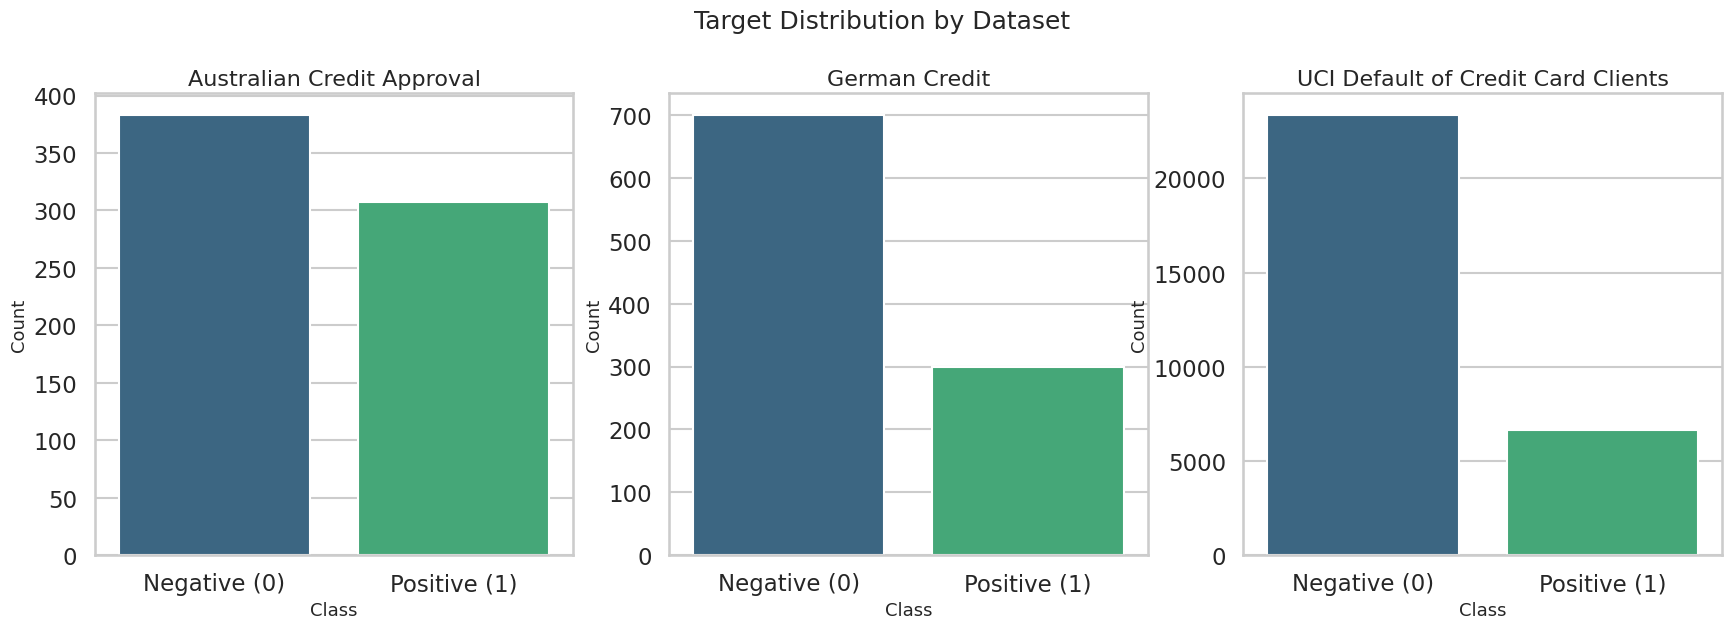

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for axis, (dataset_name, bundle) in zip(axes, DATASETS.items()):
    counts = bundle["y"].value_counts().sort_index()
    sns.barplot(
        x=["Negative (0)", "Positive (1)"],
        y=[counts.get(0, 0), counts.get(1, 0)],
        ax=axis,
        palette="viridis",
    )
    axis.set_title(bundle["display_name"])
    axis.set_xlabel("Class")
    axis.set_ylabel("Count")
plt.suptitle("Target Distribution by Dataset", y=1.02, fontsize=18)
for extension in ("png", "pdf"):
    fig.savefig(OUTPUT_DIRS["plots"] / f"target_distribution_by_dataset.{extension}")
plt.show()


## ***Section 6: Preprocessing Pipelines***

Fold-safe preprocessing is essential for valid evaluation. Any imputer, scaler, or encoder that is fit before the training-validation split leaks information from the held-out fold into the model pipeline and can inflate reported performance. We therefore build each preprocessor from the training fold only and apply the fitted transformations to the validation fold afterward.

The next cell implements dataset-specific preprocessing logic. The scientific interpretation becomes relevant during the cross-validation section, where these preprocessors are instantiated independently inside each fold.


In [8]:
def make_onehot_encoder() -> OneHotEncoder:
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(dataset_name: str, X_train: pd.DataFrame) -> ColumnTransformer:
    type_info = infer_column_types(dataset_name, X_train)

    if dataset_name == "australian":
        transformers = []
        if type_info["categorical"]:
            transformers.append(
                (
                    "categorical",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="most_frequent")),
                            ("encoder", make_onehot_encoder()),
                        ]
                    ),
                    type_info["categorical"],
                )
            )
        if type_info["numerical"]:
            transformers.append(
                (
                    "numerical",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    type_info["numerical"],
                )
            )
        return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)

    if dataset_name == "german":
        return ColumnTransformer(
            transformers=[
                (
                    "numerical",
                    Pipeline(
                        steps=[
                            ("imputer", SimpleImputer(strategy="median")),
                            ("scaler", StandardScaler()),
                        ]
                    ),
                    list(X_train.columns),
                )
            ],
            remainder="drop",
            verbose_feature_names_out=False,
        )

    if dataset_name == "default_credit":
        type_info = infer_column_types(dataset_name, X_train)
        transformers = []
        transformers.append(
            (
                "categorical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("encoder", make_onehot_encoder()),
                    ]
                ),
                type_info["categorical"],
            )
        )
        transformers.append(
            (
                "ordinal",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent"))]),
                type_info["ordinal"],
            )
        )
        transformers.append(
            (
                "numerical",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scaler", StandardScaler()),
                    ]
                ),
                type_info["numerical"],
            )
        )
        return ColumnTransformer(transformers=transformers, remainder="drop", verbose_feature_names_out=False)

    raise ValueError(f"Unknown dataset name: {dataset_name}")


def preprocess_fold(
    dataset_name: str,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, ColumnTransformer, list[str]]:
    preprocessor = build_preprocessor(dataset_name, X_train)
    X_train_processed = preprocessor.fit_transform(X_train)
    X_val_processed = preprocessor.transform(X_val)
    feature_names = list(preprocessor.get_feature_names_out())

    X_train_processed = np.asarray(X_train_processed, dtype=np.float32)
    X_val_processed = np.asarray(X_val_processed, dtype=np.float32)

    assert X_train_processed.shape[1] == X_val_processed.shape[1], "Feature dimension mismatch after preprocessing."
    return X_train_processed, X_val_processed, preprocessor, feature_names


def get_preprocessed_fold_data(
    dataset_name: str,
    fold_id: int,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
) -> dict[str, Any]:
    cache_key = (dataset_name, fold_id)
    if CONFIG["cache_preprocessed_folds"] and cache_key in PREPROCESSED_FOLD_CACHE:
        cached = PREPROCESSED_FOLD_CACHE[cache_key]
        return {
            key: value.copy() if isinstance(value, np.ndarray) else copy.deepcopy(value)
            for key, value in cached.items()
        }

    bundle = DATASETS[dataset_name]
    X_df = bundle["X"]
    y_series = bundle["y"]
    X_train_df = X_df.iloc[train_idx].reset_index(drop=True)
    X_val_df = X_df.iloc[val_idx].reset_index(drop=True)
    y_train = y_series.iloc[train_idx].to_numpy(dtype=np.int64)
    y_val = y_series.iloc[val_idx].to_numpy(dtype=np.int64)

    X_train_processed, X_val_processed, _, feature_names = preprocess_fold(
        dataset_name=dataset_name,
        X_train=X_train_df,
        X_val=X_val_df,
    )

    fold_payload = {
        "X_train_processed": X_train_processed,
        "X_val_processed": X_val_processed,
        "y_train": y_train,
        "y_val": y_val,
        "feature_names": feature_names,
        "train_idx": np.asarray(train_idx, dtype=np.int64),
        "val_idx": np.asarray(val_idx, dtype=np.int64),
    }

    if CONFIG["cache_preprocessed_folds"]:
        PREPROCESSED_FOLD_CACHE[cache_key] = {
            key: value.copy() if isinstance(value, np.ndarray) else copy.deepcopy(value)
            for key, value in fold_payload.items()
        }

    return fold_payload


## ***Section 7: SMOTE-ENN and Loss-Based Imbalance Handling***

We compare three conceptually distinct approaches to imbalance. SMOTE-ENN is a data-level intervention that oversamples the minority class while cleaning ambiguous majority samples. Weighted BCE is a loss-level intervention that increases the penalty assigned to positive-class mistakes without altering the observed training examples. Focal Loss further concentrates learning on difficult examples by down-weighting easy instances.

The next cell implements these mechanisms.

In [9]:
def apply_smoteenn(X_train: np.ndarray, y_train: np.ndarray, random_state: int) -> tuple[np.ndarray, np.ndarray]:
    sampler = SMOTEENN(random_state=random_state)
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    return X_resampled.astype(np.float32), y_resampled.astype(np.int64)


def compute_pos_weight(y_train: np.ndarray) -> torch.Tensor:
    positive_count = float(np.sum(y_train == 1))
    negative_count = float(np.sum(y_train == 0))
    positive_count = max(positive_count, 1.0)
    return torch.tensor([negative_count / positive_count], dtype=torch.float32, device=DEVICE)


def compute_focal_alpha(y_train: np.ndarray) -> float:
    positive_rate = float(np.mean(y_train))
    return float(np.clip(1.0 - positive_rate, 0.05, 0.95))


class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 0.75, gamma: float = 2.0, reduction: str = "mean") -> None:
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        probs = torch.sigmoid(logits)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_factor = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_term = alpha_factor * torch.pow(1 - pt, self.gamma)
        loss = focal_term * bce
        if self.reduction == "sum":
            return loss.sum()
        if self.reduction == "none":
            return loss
        return loss.mean()


## ***Section 8: Dataset and DataLoader Classes***

The original paper applies recurrent models to static tabular data. This is not a naturally temporal formulation, so we document our representation choice explicitly: for LSTM and GRU models, we treat the feature vector as a short sequence of scalar observations with shape `[batch, n_features, 1]`. This preserves a reproducible architectural correspondence to the reproduced models while acknowledging a conceptual limitation.

The next cell implements the dataset wrapper and dataloader factory.

In [10]:
class TabularDataset(Dataset):
    def __init__(self, features: np.ndarray, labels: np.ndarray, model_name: str) -> None:
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.model_name = model_name

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, index: int) -> tuple[torch.Tensor, torch.Tensor]:
        x = self.features[index]
        if self.model_name in {"lstm", "gru"}:
            x = x.unsqueeze(-1)
        y = self.labels[index]
        return x, y


def make_dataloader(
    features: np.ndarray,
    labels: np.ndarray,
    model_name: str,
    batch_size: int,
    shuffle: bool,
) -> DataLoader:
    dataset = TabularDataset(features=features, labels=labels, model_name=model_name)
    num_workers = CONFIG["num_workers"] if not CONFIG["quick_run"] else 0
    dataloader_kwargs = {
        "dataset": dataset,
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "pin_memory": CONFIG["pin_memory"],
        "drop_last": False,
    }
    if num_workers > 0:
        dataloader_kwargs["persistent_workers"] = CONFIG["persistent_workers"]
        dataloader_kwargs["prefetch_factor"] = CONFIG["prefetch_factor"]
    return DataLoader(**dataloader_kwargs)


## ***Section 9: Model Architectures***

We implement three model families aligned with the reproduced assignment: a feed-forward multilayer perceptron, an LSTM classifier, and a GRU classifier. All models return logits rather than probabilities so that they remain compatible with `BCEWithLogitsLoss`, its weighted variant, and the custom focal loss. Dropout is retained as a regularization mechanism across all architectures.


In [11]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim: int, hidden_units: int, dropout: float) -> None:
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, hidden_units // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units // 2, 1),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(-1)


class LSTMClassifier(nn.Module):
    def __init__(self, hidden_units: int, dropout: float) -> None:
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_units, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_units, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        outputs, _ = self.lstm(x)
        representation = outputs[:, -1, :]
        representation = self.dropout(representation)
        return self.classifier(representation).squeeze(-1)


class GRUClassifier(nn.Module):
    def __init__(self, hidden_units: int, dropout: float) -> None:
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_units, batch_first=True)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_units, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        outputs, _ = self.gru(x)
        representation = outputs[:, -1, :]
        representation = self.dropout(representation)
        return self.classifier(representation).squeeze(-1)


def build_model(model_name: str, input_dim: int) -> nn.Module:
    params = CONFIG["model_hyperparameters"][model_name]
    if model_name == "mlp":
        model = MLPClassifier(input_dim=input_dim, hidden_units=params["hidden_units"], dropout=params["dropout"])
    elif model_name == "lstm":
        model = LSTMClassifier(hidden_units=params["hidden_units"], dropout=params["dropout"])
    elif model_name == "gru":
        model = GRUClassifier(hidden_units=params["hidden_units"], dropout=params["dropout"])
    else:
        raise ValueError(f"Unknown model name: {model_name}")

    model = model.to(DEVICE)
    if CONFIG["use_dataparallel"] and torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model


def build_optimizer(model_name: str, model: nn.Module) -> torch.optim.Optimizer:
    params = CONFIG["model_hyperparameters"][model_name]
    lr = params["learning_rate"]
    optimizer_name = params["optimizer"].lower()
    if optimizer_name == "adam":
        return torch.optim.Adam(model.parameters(), lr=lr)
    if optimizer_name == "rmsprop":
        return torch.optim.RMSprop(model.parameters(), lr=lr)
    raise ValueError(f"Unsupported optimizer: {optimizer_name}")


## ***Section 10: Training and Evaluation Utilities***

This section consolidates the reusable components required for fold-level experimentation. We train on logits, track loss histories, compute both the reproduced paper metrics and stronger imbalance-aware metrics, and retain the checkpoint associated with the best validation loss within each fold. This design ensures that every downstream artifact, including tables, confusion matrices, and SHAP explanations, can be regenerated from saved outputs rather than ad hoc inspection.

The expected output of the next cell is function definition only. Metric interpretation is especially important for sensitivity and specificity because these are the paper-aligned quantities that anchor our extension back to the reproduced study.


In [12]:
def get_autocast_context(enabled: bool):
    if not enabled or not torch.cuda.is_available():
        return nullcontext()
    try:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    except TypeError:
        return torch.cuda.amp.autocast()


def extract_state_dict(model: nn.Module) -> dict[str, torch.Tensor]:
    state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    return copy.deepcopy(state_dict)


def load_state_dict_into_model(model: nn.Module, state_dict: dict[str, torch.Tensor]) -> None:
    target = model.module if isinstance(model, nn.DataParallel) else model
    target.load_state_dict(state_dict)


def compute_confusion_matrix_values(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, int]:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"tp": int(tp), "tn": int(tn), "fp": int(fp), "fn": int(fn)}


def compute_metrics(y_true: np.ndarray, y_prob: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_prob = np.asarray(y_prob, dtype=np.float64)
    y_true = np.asarray(y_true, dtype=np.int64)
    y_pred = (y_prob >= threshold).astype(int)
    cm_values = compute_confusion_matrix_values(y_true, y_pred)

    specificity_denominator = cm_values["tn"] + cm_values["fp"]
    specificity = cm_values["tn"] / specificity_denominator if specificity_denominator else 0.0

    metrics = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "sensitivity": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "tp": cm_values["tp"],
        "tn": cm_values["tn"],
        "fp": cm_values["fp"],
        "fn": cm_values["fn"],
    }

    if len(np.unique(y_true)) == 2:
        metrics["roc_auc"] = float(roc_auc_score(y_true, y_prob))
        metrics["pr_auc"] = float(average_precision_score(y_true, y_prob))
    else:
        metrics["roc_auc"] = float("nan")
        metrics["pr_auc"] = float("nan")
    return metrics


def compute_batch_correct_predictions(
    logits: torch.Tensor,
    labels: torch.Tensor,
    threshold: float,
) -> int:
    probabilities = torch.sigmoid(logits)
    predictions = (probabilities >= threshold).long().view(-1)
    targets = labels.long().view(-1)
    return int((predictions == targets).sum().item())


def train_one_epoch(
    model: nn.Module,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    scaler: torch.cuda.amp.GradScaler | None,
) -> tuple[float, float]:
    model.train()
    running_loss = 0.0
    sample_count = 0
    correct_count = 0

    for features, labels in dataloader:
        features = features.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        autocast_context = get_autocast_context(CONFIG["mixed_precision"])
        with autocast_context:
            logits = model(features)
            loss = criterion(logits, labels)

        if scaler is not None and torch.cuda.is_available():
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        batch_size = labels.shape[0]
        running_loss += float(loss.item()) * batch_size
        correct_count += compute_batch_correct_predictions(logits, labels, CONFIG["default_threshold"])
        sample_count += batch_size

    average_loss = running_loss / max(sample_count, 1)
    average_accuracy = correct_count / max(sample_count, 1)
    return average_loss, float(average_accuracy)


def evaluate_model(
    model: nn.Module,
    dataloader: DataLoader,
    criterion: nn.Module,
) -> tuple[float, float, np.ndarray, np.ndarray]:
    model.eval()
    running_loss = 0.0
    sample_count = 0
    correct_count = 0
    all_labels: list[np.ndarray] = []
    all_probs: list[np.ndarray] = []

    with torch.no_grad():
        for features, labels in dataloader:
            features = features.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            autocast_context = get_autocast_context(CONFIG["mixed_precision"])
            with autocast_context:
                logits = model(features)
                loss = criterion(logits, labels)

            probabilities = torch.sigmoid(logits)
            all_probs.append(probabilities.detach().cpu().numpy())
            all_labels.append(labels.detach().cpu().numpy())

            batch_size = labels.shape[0]
            running_loss += float(loss.item()) * batch_size
            correct_count += compute_batch_correct_predictions(logits, labels, CONFIG["default_threshold"])
            sample_count += batch_size

    y_true = np.concatenate(all_labels).astype(int)
    y_prob = np.concatenate(all_probs).astype(float)
    average_loss = running_loss / max(sample_count, 1)
    average_accuracy = correct_count / max(sample_count, 1)
    return average_loss, float(average_accuracy), y_true, y_prob


def predict_proba(model: nn.Module, dataloader: DataLoader) -> np.ndarray:
    model.eval()
    probabilities: list[np.ndarray] = []
    with torch.no_grad():
        for features, _ in dataloader:
            features = features.to(DEVICE, non_blocking=True)
            logits = model(features)
            probabilities.append(torch.sigmoid(logits).detach().cpu().numpy())
    return np.concatenate(probabilities).astype(float)


def save_history(history_rows: list[dict[str, Any]], history_path: Path) -> None:
    history_df = pd.DataFrame(history_rows)
    history_df.to_csv(history_path, index=False)


def save_json(payload: dict[str, Any], path: Path) -> None:
    with open(path, "w", encoding="utf-8") as fp:
        json.dump(payload, fp, indent=2, default=str)


def save_figure(fig: plt.Figure, stem: str, directory: Path | None = None) -> list[str]:
    directory = directory or OUTPUT_DIRS["plots"]
    saved_paths = []
    for extension in ("png", "pdf"):
        path = directory / f"{stem}.{extension}"
        fig.savefig(path)
        saved_paths.append(str(path))
    return saved_paths


## ***Section 11: Cross-Validation Experiment Runner***

Our experiments are defined at the fold level so that preprocessing, imbalance intervention, and loss construction all occur within the correct validation boundary. Each fold is responsible for its own preprocessing fit, optional SMOTE-ENN resampling, criterion selection, checkpointing, metric export, and out-of-fold prediction logging. We stratify every split because class imbalance is a first-order property of the problem and should remain stable across folds.

The next cell implements the fold runner and experiment wrapper.


In [13]:
def get_condition_criterion(condition: str, y_train: np.ndarray) -> nn.Module:
    if condition in {"baseline", "smoteenn"}:
        return nn.BCEWithLogitsLoss()
    if condition == "weighted_bce":
        return nn.BCEWithLogitsLoss(pos_weight=compute_pos_weight(y_train))
    if condition == "focal_loss":
        return FocalLoss(alpha=compute_focal_alpha(y_train), gamma=2.0)
    raise ValueError(f"Unknown condition: {condition}")


def rebuild_splits(dataset_name: str, y: pd.Series) -> list[tuple[np.ndarray, np.ndarray]]:
    cache_key = (dataset_name, len(y), CONFIG["n_splits"])
    if cache_key not in SPLIT_CACHE:
        splitter = StratifiedKFold(
            n_splits=CONFIG["n_splits"],
            shuffle=True,
            random_state=CONFIG["seed"],
        )
        SPLIT_CACHE[cache_key] = list(splitter.split(np.zeros(len(y)), y))
    return SPLIT_CACHE[cache_key]


def run_single_fold(
    dataset_name: str,
    model_name: str,
    condition: str,
    fold_id: int,
    train_idx: np.ndarray,
    val_idx: np.ndarray,
) -> dict[str, Any]:
    start_time = time.time()
    fold_data = get_preprocessed_fold_data(
        dataset_name=dataset_name,
        fold_id=fold_id,
        train_idx=train_idx,
        val_idx=val_idx,
    )
    X_train_processed = fold_data["X_train_processed"]
    X_val_processed = fold_data["X_val_processed"]
    y_train = fold_data["y_train"]
    y_val = fold_data["y_val"]
    feature_names = fold_data["feature_names"]

    if condition == "smoteenn":
        X_train_processed, y_train = apply_smoteenn(
            X_train_processed,
            y_train,
            random_state=CONFIG["seed"] + fold_id,
        )

    params = CONFIG["model_hyperparameters"][model_name]
    train_loader = make_dataloader(
        features=X_train_processed,
        labels=y_train,
        model_name=model_name,
        batch_size=params["batch_size"],
        shuffle=True,
    )
    eval_batch_size = params["batch_size"] * CONFIG["eval_batch_multiplier"]
    val_loader = make_dataloader(
        features=X_val_processed,
        labels=y_val,
        model_name=model_name,
        batch_size=eval_batch_size,
        shuffle=False,
    )

    model = build_model(model_name=model_name, input_dim=X_train_processed.shape[1])
    optimizer = build_optimizer(model_name=model_name, model=model)
    criterion = get_condition_criterion(condition=condition, y_train=y_train)
    scaler = torch.cuda.amp.GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())

    best_state = extract_state_dict(model)
    best_val_loss = math.inf
    epochs_without_improvement = 0
    history_rows: list[dict[str, Any]] = []

    for epoch in range(1, CONFIG["num_epochs"] + 1):
        train_loss, train_accuracy = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_loss, val_accuracy, _, _ = evaluate_model(model, val_loader, criterion)
        history_rows.append(
            {
                "epoch": epoch,
                "train_loss": train_loss,
                "train_accuracy": train_accuracy,
                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
            }
        )

        if val_loss + CONFIG["early_stopping_min_delta"] < best_val_loss:
            best_val_loss = val_loss
            best_state = extract_state_dict(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= CONFIG["early_stopping_patience"]:
            break

    load_state_dict_into_model(model, best_state)
    final_val_loss, final_val_accuracy, y_true, y_prob = evaluate_model(model, val_loader, criterion)
    final_metrics = compute_metrics(y_true, y_prob, threshold=CONFIG["default_threshold"])

    checkpoint_path = None
    if model_name == "mlp" or CONFIG["save_non_mlp_checkpoints"]:
        checkpoint_name = f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}.pt"
        checkpoint_path = OUTPUT_DIRS["models"] / checkpoint_name
        torch.save(
            {
                "dataset_name": dataset_name,
                "model_name": model_name,
                "condition": condition,
                "fold_id": fold_id,
                "state_dict": best_state,
                "feature_names": feature_names,
                "input_dim": X_train_processed.shape[1],
            },
            checkpoint_path,
        )

    history_path = OUTPUT_DIRS["histories"] / f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}_history.csv"
    save_history(history_rows=history_rows, history_path=history_path)

    metrics_record = {
        "dataset": dataset_name,
        "model": model_name,
        "condition": condition,
        "fold_id": fold_id,
        "status": "success",
        "n_train": int(len(train_idx)),
        "n_val": int(len(val_idx)),
        "n_train_after_sampling": int(len(y_train)),
        "epochs_ran": int(len(history_rows)),
        "final_train_loss": float(history_rows[-1]["train_loss"]),
        "final_train_accuracy": float(history_rows[-1]["train_accuracy"]),
        "best_val_accuracy": float(max(row["val_accuracy"] for row in history_rows)),
        "final_val_accuracy": float(final_val_accuracy),
        "val_loss": float(final_val_loss),
        "history_path": str(history_path),
        "checkpoint_path": str(checkpoint_path) if checkpoint_path is not None else None,
        "feature_count_after_preprocessing": int(X_train_processed.shape[1]),
        "feature_names_path": str(OUTPUT_DIRS["models"] / f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}_features.json"),
        "runtime_seconds": float(time.time() - start_time),
        **final_metrics,
    }

    save_json(
        {"feature_names": feature_names, "train_indices": train_idx.tolist(), "val_indices": val_idx.tolist()},
        OUTPUT_DIRS["models"] / f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}_features.json",
    )
    save_json(metrics_record, OUTPUT_DIRS["metrics"] / f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}_metrics.json")

    prediction_records = pd.DataFrame(
        {
            "dataset": dataset_name,
            "model": model_name,
            "condition": condition,
            "fold_id": fold_id,
            "row_index": val_idx,
            "y_true": y_true,
            "y_prob": y_prob,
            "y_pred": (y_prob >= CONFIG["default_threshold"]).astype(int),
        }
    )
    prediction_path = OUTPUT_DIRS["metrics"] / f"{dataset_name}_{model_name}_{condition}_fold{fold_id:02d}_predictions.csv"
    prediction_records.to_csv(prediction_path, index=False)
    metrics_record["prediction_path"] = str(prediction_path)

    logger.info(
        f"Completed {dataset_name} | {model_name} | {condition} | fold {fold_id} | "
        f"accuracy={metrics_record['accuracy']:.4f} | pr_auc={metrics_record['pr_auc']:.4f}"
    )
    return metrics_record


def run_experiment(dataset_name: str, model_name: str, condition: str) -> list[dict[str, Any]]:
    bundle = DATASETS[dataset_name]
    split_indices = rebuild_splits(dataset_name, bundle["y"])
    results: list[dict[str, Any]] = []

    progress = tqdm(
        enumerate(split_indices, start=1),
        total=len(split_indices),
        desc=f"{dataset_name}-{model_name}-{condition}",
        leave=False,
    )
    for fold_id, (train_idx, val_idx) in progress:
        try:
            result = run_single_fold(
                dataset_name=dataset_name,
                model_name=model_name,
                condition=condition,
                fold_id=fold_id,
                train_idx=train_idx,
                val_idx=val_idx,
            )
        except Exception as exc:
            logger.exception(
                f"Failed {dataset_name} | {model_name} | {condition} | fold {fold_id}: {exc}"
            )
            result = {
                "dataset": dataset_name,
                "model": model_name,
                "condition": condition,
                "fold_id": fold_id,
                "status": "failed",
                "error_message": str(exc),
            }
        results.append(result)
    return results


## ***Section 12: Parallel Execution Strategy***

Kaggle T4 x2 hardware is best used primarily through model-level GPU acceleration rather than by launching many concurrent GPU training jobs. Uncontrolled GPU parallelism often harms reproducibility, increases memory fragmentation, and can trigger out-of-memory failures. We therefore keep training sequential when CUDA is available, while still exposing a safe optional path for CPU-only parallel execution and for independent post-processing tasks such as table export or figure rendering.

The next cell defines the high-level experiment scheduler.

In [14]:
from concurrent.futures import ThreadPoolExecutor, as_completed


def run_all_experiments() -> pd.DataFrame:
    experiment_grid = [
        (dataset_name, model_name, condition)
        for dataset_name in CONFIG["datasets"]
        for model_name in CONFIG["models"]
        for condition in CONFIG["conditions"]
    ]

    all_results: list[dict[str, Any]] = []

    use_cpu_parallelism = CONFIG["parallel_experiments"] and not torch.cuda.is_available()
    if use_cpu_parallelism:
        logger.info("Parallel CPU execution enabled.")
        with ThreadPoolExecutor(max_workers=CONFIG["max_parallel_workers"]) as executor:
            future_map = {
                executor.submit(run_experiment, dataset_name, model_name, condition): (dataset_name, model_name, condition)
                for dataset_name, model_name, condition in experiment_grid
            }
            for future in tqdm(as_completed(future_map), total=len(future_map), desc="Experiment groups"):
                all_results.extend(future.result())
    else:
        logger.info("Sequential experiment execution selected for stability.")
        for dataset_name, model_name, condition in tqdm(experiment_grid, desc="Experiment groups"):
            all_results.extend(run_experiment(dataset_name, model_name, condition))

    all_fold_metrics = pd.DataFrame(all_results)
    all_fold_metrics.to_csv(OUTPUT_DIRS["metrics"] / "all_fold_metrics.csv", index=False)
    return all_fold_metrics


## ***Section 13: Run Experiments***

This is the main execution section of the notebook. All dataset-model-condition combinations are dispatched from a single source of truth so that no result table or figure depends on manual transcription. In `QUICK_RUN` mode, the notebook executes a reduced number of folds and epochs for smoke testing; in full mode, it performs the complete stratified evaluation intended for report writing.

The outputs of the next cell are the master fold-metrics file, the aggregated history JSON, and the saved experiment configuration. If `QUICK_RUN` is enabled, we should interpret every result in this notebook as a pipeline validation artifact rather than a final research conclusion.


In [15]:
if CONFIG["quick_run"]:
    logger.warning("QUICK_RUN is enabled. Report conclusions should not be drawn from the reduced experiment sweep.")

save_json(CONFIG, OUTPUT_DIRS["root"] / "experiment_config.json")

all_fold_metrics_df = run_all_experiments()

history_payload = {}
for history_file in sorted(OUTPUT_DIRS["histories"].glob("*_history.csv")):
    history_payload[history_file.stem] = pd.read_csv(history_file).to_dict(orient="records")

save_json(history_payload, OUTPUT_DIRS["histories"] / "all_histories.json")
display(all_fold_metrics_df.head())
logger.info(f"Completed experiment grid with {len(all_fold_metrics_df)} fold-level records.")


2026-04-25 13:04:30,615 | INFO | Sequential experiment execution selected for stability.


Experiment groups:   0%|          | 0/36 [00:00<?, ?it/s]

australian-mlp-baseline:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-25 13:04:35,503 | INFO | Completed australian | mlp | baseline | fold 1 | accuracy=0.8841 | pr_auc=0.9556
2026-04-25 13:04:37,992 | INFO | Completed australian | mlp | baseline | fold 2 | accuracy=0.8841 | pr_auc=0.8723
2026-04-25 13:04:41,361 | INFO | Completed australian | mlp | baseline | fold 3 | accuracy=0.9130 | pr_auc=0.9448
2026-04-25 13:04:42,957 | INFO | Completed australian | mlp | baseline | fold 4 | accuracy=0.7536 | pr_auc=0.8423
2026-04-25 13:04:44,873 | INFO | Completed australian | mlp | baseline | fold 5 | accuracy=0.8696 | pr_auc=0.8746
2026-04-25 13:04:47,229 | INFO | Completed australian | mlp | baseline | fold 6 | accuracy=0.8841 | pr_auc=0.9661
2026-04-25 13:04:49,105 | INFO | Completed australian | mlp | baseline | fold 7 | accuracy=0.7536 | pr_auc=0.8822
2026-04-25 13:04:51,199 | INFO | Completed australian | mlp | baseline | fold 8 | accuracy=0.8261 | pr_auc=0.9381
2026-04-25 13:04:53,347 | INFO | Completed australian | mlp | baseline | fold 9 | accura

australian-mlp-smoteenn:   0%|          | 0/10 [00:00<?, ?it/s]

...

2026-04-25 15:24:24,427 | INFO | Completed default_credit | gru | weighted_bce | fold 1 | accuracy=0.7553 | pr_auc=0.5387
2026-04-25 15:25:57,764 | INFO | Completed default_credit | gru | weighted_bce | fold 2 | accuracy=0.7673 | pr_auc=0.5694
2026-04-25 15:26:55,471 | INFO | Completed default_credit | gru | weighted_bce | fold 3 | accuracy=0.7637 | pr_auc=0.5075
2026-04-25 15:28:03,641 | INFO | Completed default_credit | gru | weighted_bce | fold 4 | accuracy=0.7607 | pr_auc=0.5654
2026-04-25 15:29:19,623 | INFO | Completed default_credit | gru | weighted_bce | fold 5 | accuracy=0.7607 | pr_auc=0.5236
2026-04-25 15:30:42,471 | INFO | Completed default_credit | gru | weighted_bce | fold 6 | accuracy=0.7717 | pr_auc=0.5651
2026-04-25 15:32:29,158 | INFO | Completed default_credit | gru | weighted_bce | fold 7 | accuracy=0.7697 | pr_auc=0.5639
2026-04-25 15:33:34,967 | INFO | Completed default_credit | gru | weighted_bce | fold 8 | accuracy=0.7827 | pr_auc=0.5571
2026-04-25 15:34:53,947 

default_credit-gru-focal_loss:   0%|          | 0/10 [00:00<?, ?it/s]

2026-04-25 15:37:44,970 | INFO | Completed default_credit | gru | focal_loss | fold 1 | accuracy=0.7663 | pr_auc=0.5267
2026-04-25 15:38:41,910 | INFO | Completed default_credit | gru | focal_loss | fold 2 | accuracy=0.7923 | pr_auc=0.5694
2026-04-25 15:40:12,409 | INFO | Completed default_credit | gru | focal_loss | fold 3 | accuracy=0.7400 | pr_auc=0.5086
2026-04-25 15:42:07,669 | INFO | Completed default_credit | gru | focal_loss | fold 4 | accuracy=0.7537 | pr_auc=0.5741
2026-04-25 15:43:55,624 | INFO | Completed default_credit | gru | focal_loss | fold 5 | accuracy=0.7757 | pr_auc=0.5214
2026-04-25 15:44:52,469 | INFO | Completed default_credit | gru | focal_loss | fold 6 | accuracy=0.7783 | pr_auc=0.5666
2026-04-25 15:46:27,342 | INFO | Completed default_credit | gru | focal_loss | fold 7 | accuracy=0.7460 | pr_auc=0.5550
2026-04-25 15:47:28,748 | INFO | Completed default_credit | gru | focal_loss | fold 8 | accuracy=0.7697 | pr_auc=0.5461
2026-04-25 15:48:51,243 | INFO | Complet

,dataset,model,condition,fold_id,status,n_train,n_val,n_train_after_sampling,epochs_ran,final_train_loss,...,precision,f1,balanced_accuracy,tp,tn,fp,fn,roc_auc,pr_auc,prediction_path
0,australian,mlp,baseline,1,success,621,69,621,11,0.293687,...,0.805556,0.878788,0.893590,29,32,7,1,0.964957,0.955645,/kaggle/working/assignment3_outputs/metrics/au...
1,australian,mlp,baseline,2,success,621,69,621,13,0.293574,...,0.843750,0.870968,0.885897,27,34,5,3,0.942735,0.872258,/kaggle/working/assignment3_outputs/metrics/au...
2,australian,mlp,baseline,3,success,621,69,621,17,0.270675,...,0.833333,0.909091,0.923077,30,33,6,0,0.976068,0.944768,/kaggle/working/assignment3_outputs/metrics/au...
3,australian,mlp,baseline,4,success,621,69,621,7,0.293757,...,0.791667,0.690909,0.740662,19,33,5,12,0.837436,0.842305,/kaggle/working/assignment3_outputs/metrics/au...
4,australian,mlp,baseline,5,success,621,69,621,9,0.287732,...,0.892857,0.847458,0.863752,25,35,3,6,0.901528,0.874623,/kaggle/working/assignment3_outputs/metrics/au...


2026-04-25 15:51:19,489 | INFO | Completed experiment grid with 360 fold-level records.


## ***Section 14: Aggregate Results***

Fold-level metrics are useful for uncertainty quantification, but they are too granular for direct report writing. We therefore aggregate results across folds to obtain the mean, standard deviation, and median for every evaluation metric under every dataset-model-condition combination. These tables are written programmatically from the master fold file to prevent transcription errors.

The next cell computes the aggregate tables and exports two report-facing views: a paper-metric table containing accuracy, sensitivity, and specificity, and an extended table containing precision, F1-score, ROC-AUC, PR-AUC, and balanced accuracy. Interpretation should focus on patterns rather than isolated maxima, especially where the standard deviation remains large.


In [16]:
successful_folds_df = all_fold_metrics_df.query("status == 'success'").copy()

aggregate_metrics_df = (
    successful_folds_df.groupby(["dataset", "model", "condition"])
    .agg(
        accuracy_mean=("accuracy", "mean"),
        accuracy_std=("accuracy", "std"),
        accuracy_median=("accuracy", "median"),
        sensitivity_mean=("sensitivity", "mean"),
        sensitivity_std=("sensitivity", "std"),
        specificity_mean=("specificity", "mean"),
        specificity_std=("specificity", "std"),
        precision_mean=("precision", "mean"),
        precision_std=("precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        pr_auc_mean=("pr_auc", "mean"),
        pr_auc_std=("pr_auc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_std=("balanced_accuracy", "std"),
        val_loss_mean=("val_loss", "mean"),
        runtime_seconds_mean=("runtime_seconds", "mean"),
        fold_count=("fold_id", "count"),
    )
    .reset_index()
    .sort_values(["dataset", "model", "condition"])
)

aggregate_metrics_df.to_csv(OUTPUT_DIRS["metrics"] / "aggregate_metrics.csv", index=False)

paper_metrics_table = aggregate_metrics_df[
    [
        "dataset",
        "model",
        "condition",
        "accuracy_mean",
        "accuracy_std",
        "sensitivity_mean",
        "sensitivity_std",
        "specificity_mean",
        "specificity_std",
    ]
].copy()
paper_metrics_table.to_csv(OUTPUT_DIRS["tables"] / "paper_metrics_table.csv", index=False)

extended_metrics_table = aggregate_metrics_df[
    [
        "dataset",
        "model",
        "condition",
        "precision_mean",
        "precision_std",
        "f1_mean",
        "f1_std",
        "roc_auc_mean",
        "roc_auc_std",
        "pr_auc_mean",
        "pr_auc_std",
        "balanced_accuracy_mean",
        "balanced_accuracy_std",
    ]
].copy()
extended_metrics_table.to_csv(OUTPUT_DIRS["tables"] / "extended_metrics_table.csv", index=False)

training_metric_columns = {
    "epochs_ran",
    "final_train_loss",
    "final_train_accuracy",
    "best_val_accuracy",
}
if training_metric_columns.issubset(successful_folds_df.columns):
    training_source_df = successful_folds_df.copy()
else:
    history_enrichment_rows = []
    for _, fold_row in successful_folds_df.iterrows():
        history_df = pd.read_csv(fold_row["history_path"])
        history_enrichment_rows.append(
            {
                "dataset": fold_row["dataset"],
                "model": fold_row["model"],
                "condition": fold_row["condition"],
                "fold_id": fold_row["fold_id"],
                "epochs_ran": int(history_df["epoch"].max()),
                "final_train_loss": float(history_df["train_loss"].iloc[-1]),
                "final_train_accuracy": float(history_df["train_accuracy"].iloc[-1]) if "train_accuracy" in history_df.columns else float("nan"),
                "best_val_accuracy": float(history_df["val_accuracy"].max()) if "val_accuracy" in history_df.columns else float("nan"),
            }
        )
    training_source_df = successful_folds_df.merge(
        pd.DataFrame(history_enrichment_rows),
        on=["dataset", "model", "condition", "fold_id"],
        how="left",
    )

training_dynamics_table = (
    training_source_df.groupby(["dataset", "model", "condition"])
    .agg(
        epochs_ran_mean=("epochs_ran", "mean"),
        final_train_loss_mean=("final_train_loss", "mean"),
        final_train_accuracy_mean=("final_train_accuracy", "mean"),
        final_train_accuracy_std=("final_train_accuracy", "std"),
        best_val_accuracy_mean=("best_val_accuracy", "mean"),
        best_val_accuracy_std=("best_val_accuracy", "std"),
    )
    .reset_index()
    .sort_values(["dataset", "model", "condition"])
)
training_dynamics_table.to_csv(OUTPUT_DIRS["tables"] / "training_dynamics_table.csv", index=False)

performance_overview_df = aggregate_metrics_df.merge(
    training_dynamics_table,
    on=["dataset", "model", "condition"],
    how="left",
)
performance_overview_df = performance_overview_df[
    [
        "dataset",
        "model",
        "condition",
        "accuracy_mean",
        "balanced_accuracy_mean",
        "pr_auc_mean",
        "final_train_accuracy_mean",
        "best_val_accuracy_mean",
        "epochs_ran_mean",
        "val_loss_mean",
    ]
].copy()
performance_overview_df.to_csv(OUTPUT_DIRS["tables"] / "performance_overview_table.csv", index=False)

display(performance_overview_df.head(12).round(4))
display(aggregate_metrics_df.head(12).round(4))


,dataset,model,condition,accuracy_mean,balanced_accuracy_mean,pr_auc_mean,final_train_accuracy_mean,best_val_accuracy_mean,epochs_ran_mean,val_loss_mean
0,australian,gru,baseline,0.7899,0.7852,0.8261,0.7841,0.8130,19.5,0.4563
1,australian,gru,focal_loss,0.8014,0.7979,0.8371,0.7890,0.8246,20.4,0.0579
2,australian,gru,smoteenn,0.7507,0.7417,0.7942,0.8321,0.7783,14.4,0.5003
3,australian,gru,weighted_bce,0.7652,0.7630,0.8123,0.7754,0.7971,19.7,0.5481
4,australian,lstm,baseline,0.8000,0.7935,0.8439,0.7760,0.8188,24.2,0.4616
5,australian,lstm,focal_loss,0.7710,0.7681,0.8129,0.7593,0.7986,16.8,0.0625
6,australian,lstm,smoteenn,0.7348,0.7201,0.7857,0.7573,0.7594,16.6,0.5201
7,australian,lstm,weighted_bce,0.7855,0.7834,0.8365,0.7427,0.8014,20.7,0.5310
8,australian,mlp,baseline,0.8551,0.8531,0.9154,0.8826,0.8783,11.8,0.3254
9,australian,mlp,focal_loss,0.8623,0.8621,0.9213,0.8890,0.8783,12.0,0.0423


,dataset,model,condition,accuracy_mean,accuracy_std,accuracy_median,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,...,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,val_loss_mean,runtime_seconds_mean,fold_count
0,australian,gru,baseline,0.7899,0.0932,0.7536,0.7431,0.1535,0.8273,0.0662,...,0.1187,0.8509,0.0924,0.8261,0.1099,0.7852,0.0984,0.4563,2.3053,10
1,australian,gru,focal_loss,0.8014,0.0826,0.8043,0.7629,0.1291,0.8329,0.0656,...,0.1007,0.8606,0.0819,0.8371,0.1027,0.7979,0.0866,0.0579,2.6162,10
2,australian,gru,smoteenn,0.7507,0.0853,0.7101,0.6615,0.1549,0.8219,0.0756,...,0.1161,0.8236,0.0742,0.7942,0.0899,0.7417,0.0904,0.5003,1.5607,10
3,australian,gru,weighted_bce,0.7652,0.0819,0.7754,0.7431,0.1349,0.7829,0.0560,...,0.1022,0.8377,0.0762,0.8123,0.0870,0.7630,0.0867,0.5481,2.3901,10
4,australian,lstm,baseline,0.8000,0.0713,0.7899,0.7363,0.1384,0.8507,0.0574,...,0.0963,0.8589,0.0636,0.8439,0.0677,0.7935,0.0768,0.4616,2.9300,10
5,australian,lstm,focal_loss,0.7710,0.0760,0.7536,0.7429,0.1223,0.7933,0.0865,...,0.0946,0.8401,0.0766,0.8129,0.0928,0.7681,0.0783,0.0625,2.1938,10
6,australian,lstm,smoteenn,0.7348,0.1032,0.7246,0.5785,0.2625,0.8617,0.0970,...,0.2514,0.8198,0.0813,0.7857,0.0944,0.7201,0.1156,0.5201,1.8049,10
7,australian,lstm,weighted_bce,0.7855,0.0778,0.7826,0.7631,0.1154,0.8036,0.0985,...,0.0862,0.8566,0.0671,0.8365,0.0719,0.7834,0.0788,0.5310,2.5178,10
8,australian,mlp,baseline,0.8551,0.0655,0.8768,0.8286,0.1399,0.8775,0.0574,...,0.0876,0.9312,0.0444,0.9154,0.0463,0.8531,0.0714,0.3254,2.5341,10
9,australian,mlp,focal_loss,0.8623,0.0577,0.8768,0.8545,0.1198,0.8696,0.0627,...,0.0720,0.9351,0.0407,0.9213,0.0376,0.8621,0.0620,0.0423,2.4945,10


## ***Section 15: Statistical Significance Testing***

Aggregate means alone do not reveal whether observed differences are stable across folds. We therefore conduct paired statistical comparisons using fold-aligned scores. The Wilcoxon signed-rank test is used as the primary non-parametric comparison, with the paired t-test reported as a secondary reference. We interpret p-values cautiously because ten folds provide only a modest paired sample and the folds are not fully independent in the strict inferential sense.

The output of the next cell is a table of paired comparisons saved to disk. Interpretation should emphasize effect direction and practical magnitude alongside p-values rather than treating statistical significance as a binary truth criterion.


In [17]:
def paired_test_records(metric_name: str, left: pd.DataFrame, right: pd.DataFrame) -> dict[str, Any]:
    merged = left[["fold_id", metric_name]].merge(
        right[["fold_id", metric_name]],
        on="fold_id",
        suffixes=("_left", "_right"),
    ).dropna()

    x = merged[f"{metric_name}_left"].to_numpy()
    y = merged[f"{metric_name}_right"].to_numpy()
    result = {
        "metric": metric_name,
        "n_pairs": int(len(merged)),
        "left_mean": float(np.mean(x)) if len(x) else float("nan"),
        "right_mean": float(np.mean(y)) if len(y) else float("nan"),
        "mean_difference_left_minus_right": float(np.mean(x - y)) if len(x) else float("nan"),
        "wilcoxon_statistic": float("nan"),
        "wilcoxon_pvalue": float("nan"),
        "ttest_statistic": float("nan"),
        "ttest_pvalue": float("nan"),
    }

    if len(merged) >= 2:
        try:
            wilcoxon_stat, wilcoxon_p = stats.wilcoxon(x, y)
            result["wilcoxon_statistic"] = float(wilcoxon_stat)
            result["wilcoxon_pvalue"] = float(wilcoxon_p)
        except ValueError:
            pass

        try:
            t_stat, t_p = stats.ttest_rel(x, y, nan_policy="omit")
            result["ttest_statistic"] = float(t_stat)
            result["ttest_pvalue"] = float(t_p)
        except Exception:
            pass

    return result


comparison_pairs = [
    ("baseline", "smoteenn"),
    ("baseline", "weighted_bce"),
    ("smoteenn", "weighted_bce"),
    ("smoteenn", "focal_loss"),
]
comparison_metrics = ["accuracy", "f1", "pr_auc", "balanced_accuracy"]

statistical_test_rows = []
for (dataset_name, model_name), group_df in successful_folds_df.groupby(["dataset", "model"]):
    for left_condition, right_condition in comparison_pairs:
        left_df = group_df[group_df["condition"] == left_condition]
        right_df = group_df[group_df["condition"] == right_condition]
        for metric_name in comparison_metrics:
            row = paired_test_records(metric_name=metric_name, left=left_df, right=right_df)
            row.update(
                {
                    "dataset": dataset_name,
                    "model": model_name,
                    "comparison": f"{left_condition}_vs_{right_condition}",
                    "left_condition": left_condition,
                    "right_condition": right_condition,
                }
            )
            statistical_test_rows.append(row)

statistical_tests_df = pd.DataFrame(statistical_test_rows)
statistical_tests_df.to_csv(OUTPUT_DIRS["metrics"] / "statistical_tests.csv", index=False)
display(statistical_tests_df.head(12))


,metric,n_pairs,left_mean,right_mean,mean_difference_left_minus_right,wilcoxon_statistic,wilcoxon_pvalue,ttest_statistic,ttest_pvalue,dataset,model,comparison,left_condition,right_condition
0,accuracy,10,0.789855,0.750725,0.039130,8.5,0.105469,1.734432,0.116869,australian,gru,baseline_vs_smoteenn,baseline,smoteenn
1,f1,10,0.753998,0.696320,0.057679,10.5,0.087891,1.983208,0.078652,australian,gru,baseline_vs_smoteenn,baseline,smoteenn
2,pr_auc,10,0.826082,0.794159,0.031924,15.0,0.232422,1.528333,0.160780,australian,gru,baseline_vs_smoteenn,baseline,smoteenn
3,balanced_accuracy,10,0.785223,0.741718,0.043506,10.0,0.083984,1.837359,0.099328,australian,gru,baseline_vs_smoteenn,baseline,smoteenn
4,accuracy,10,0.789855,0.765217,0.024638,18.0,0.632812,1.128882,0.288138,australian,gru,baseline_vs_weighted_bce,baseline,weighted_bce
5,f1,10,0.753998,0.734474,0.019525,26.0,0.921875,0.722246,0.488484,australian,gru,baseline_vs_weighted_bce,baseline,weighted_bce
6,pr_auc,10,0.826082,0.812276,0.013806,27.0,1.000000,0.978979,0.353171,australian,gru,baseline_vs_weighted_bce,baseline,weighted_bce
7,balanced_accuracy,10,0.785223,0.763023,0.022200,24.0,0.769531,0.954368,0.364826,australian,gru,baseline_vs_weighted_bce,baseline,weighted_bce
8,accuracy,10,0.750725,0.765217,-0.014493,10.5,0.609375,-0.807573,0.440158,australian,gru,smoteenn_vs_weighted_bce,smoteenn,weighted_bce
9,f1,10,0.696320,0.734474,-0.038154,8.0,0.195312,-1.602760,0.143451,australian,gru,smoteenn_vs_weighted_bce,smoteenn,weighted_bce


## ***Section 16: Visualizations***

Figures help us move from scalar metrics to broader behavioural interpretation. We therefore generate metric comparison charts, representative learning curves, aggregated confusion matrices, and a heatmap summarizing overall performance. Each figure is saved in both PNG and PDF format where practical so that the report can reuse the exact notebook outputs without redrawing plots manually.

The next cell constructs and saves the figure set. Interpretation should focus on whether loss-based methods improve minority-class detection without inducing the instability that can accompany aggressive resampling.


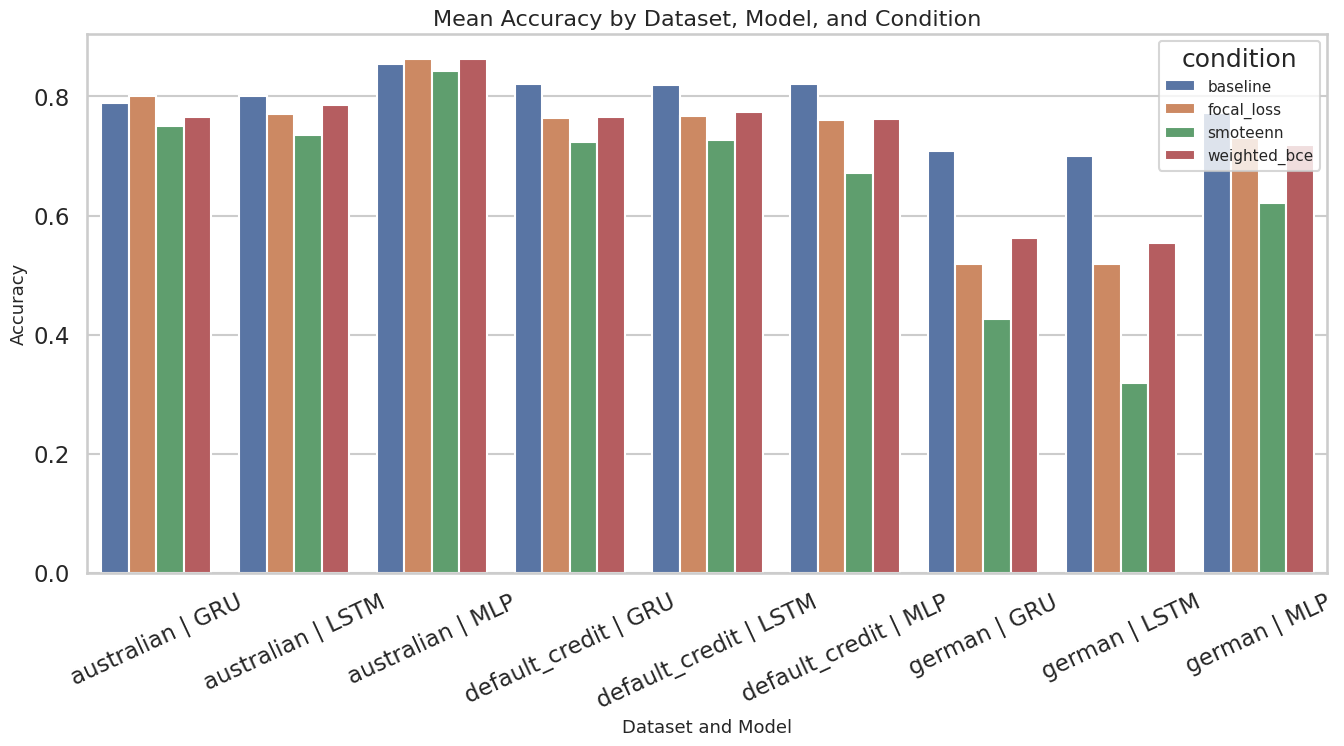

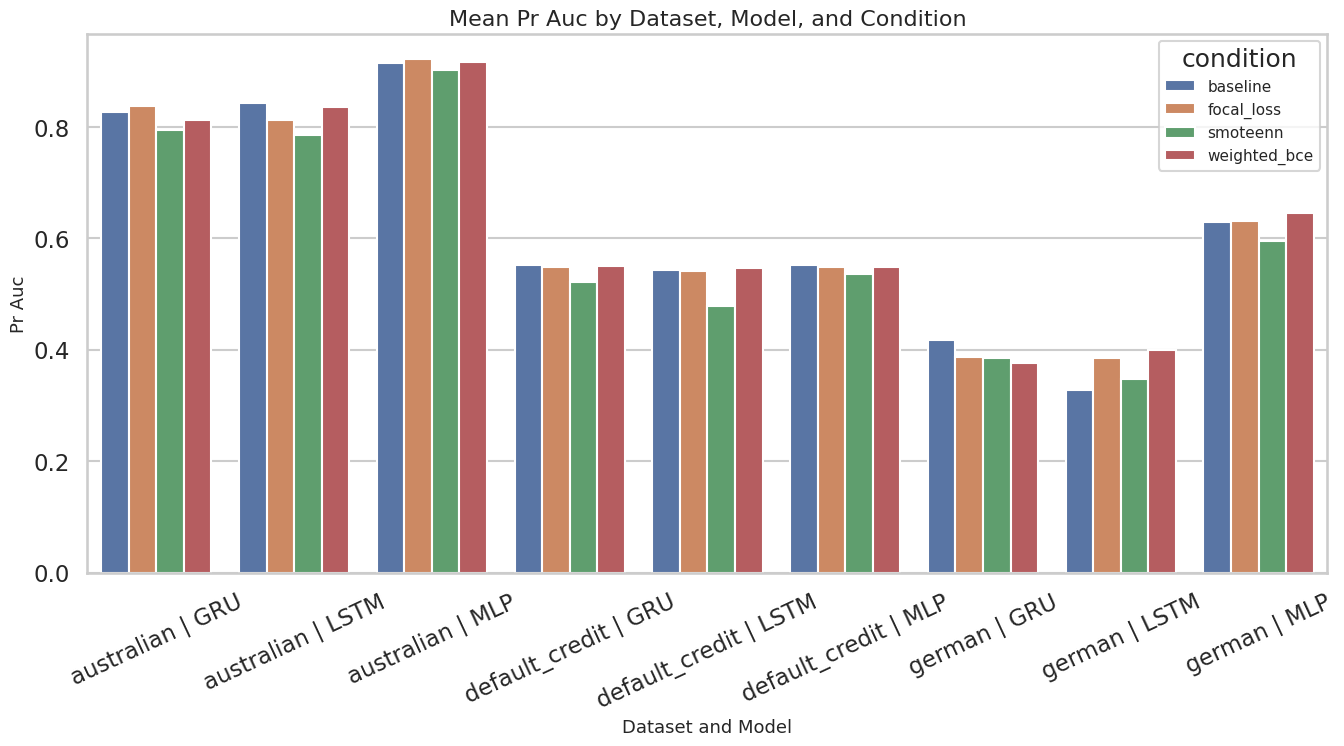

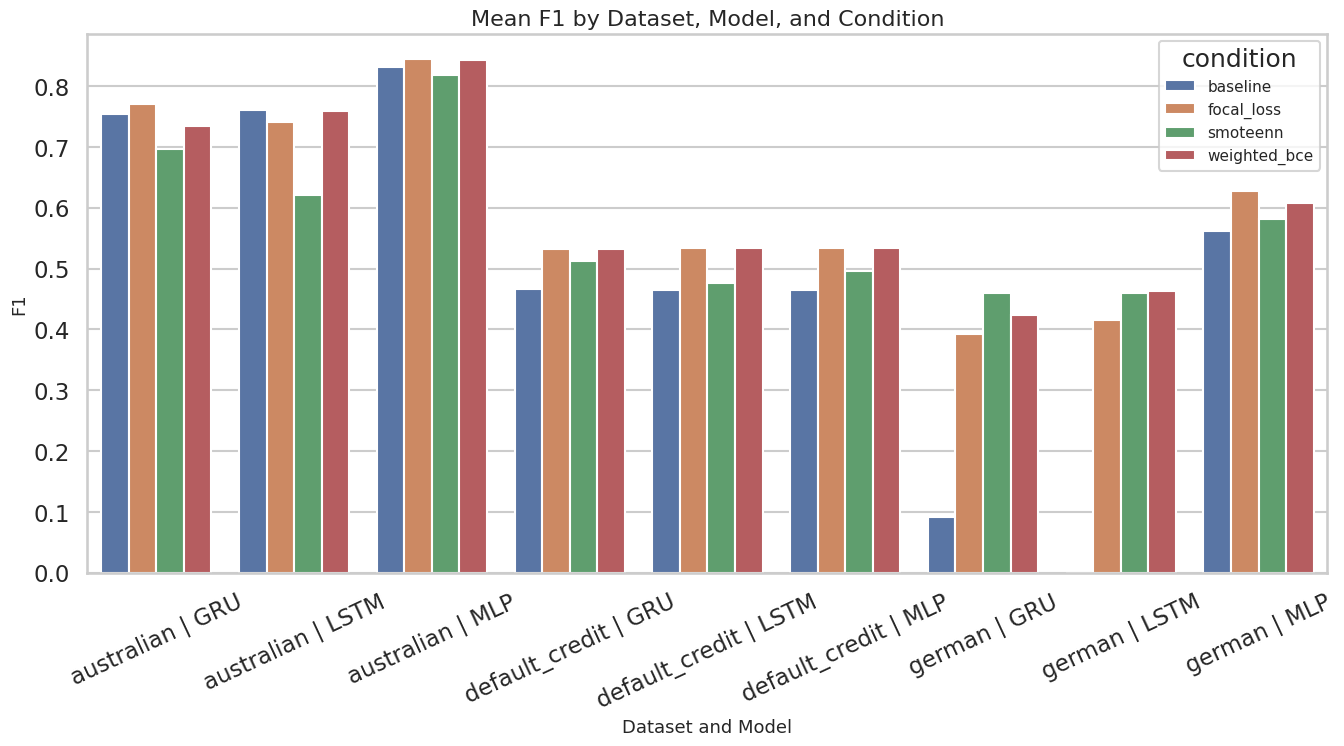

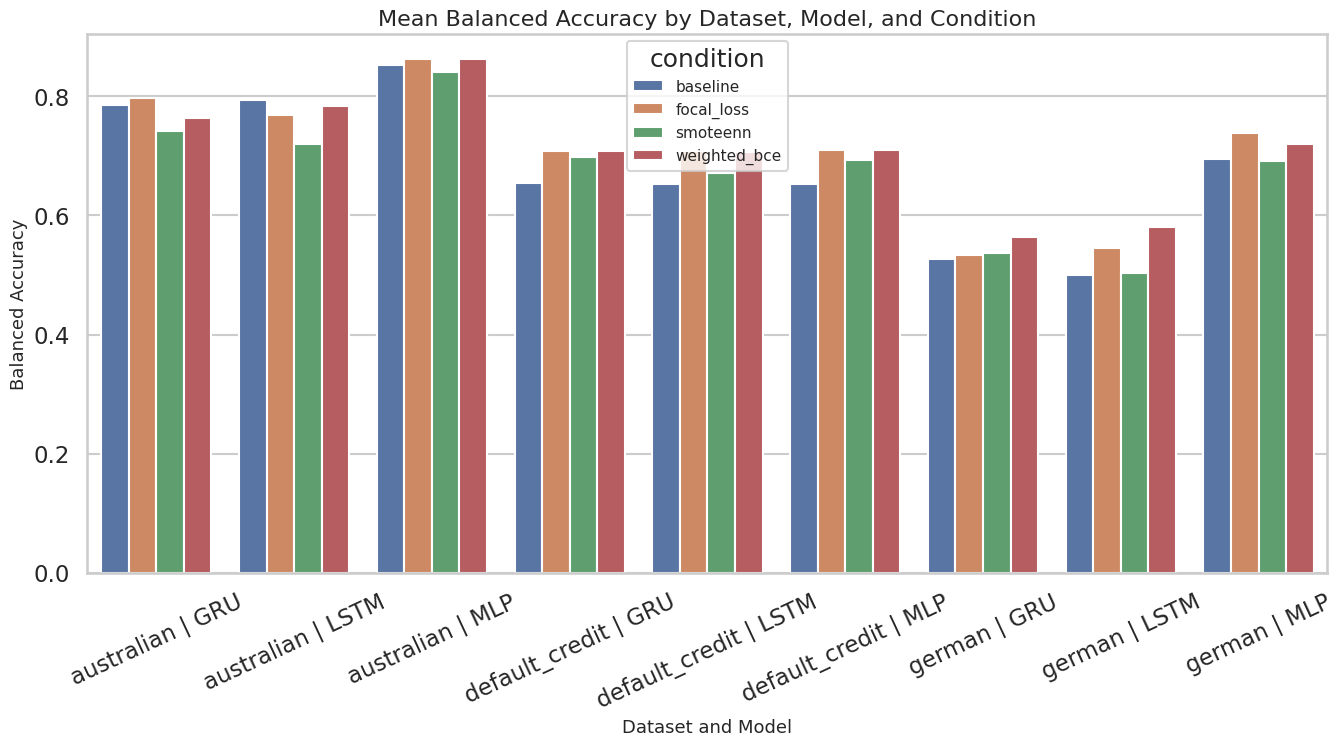

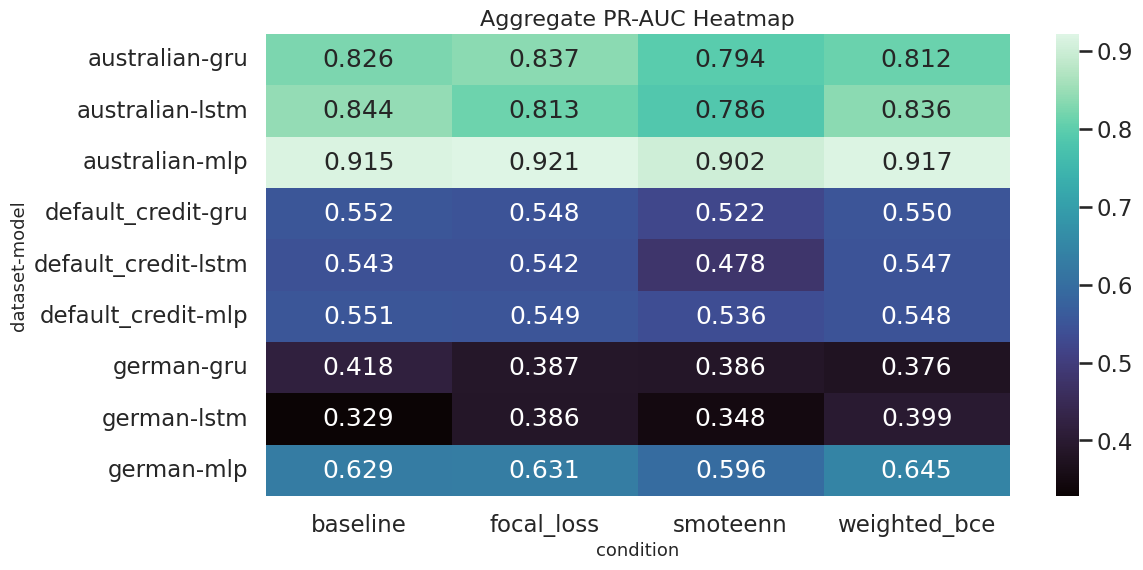

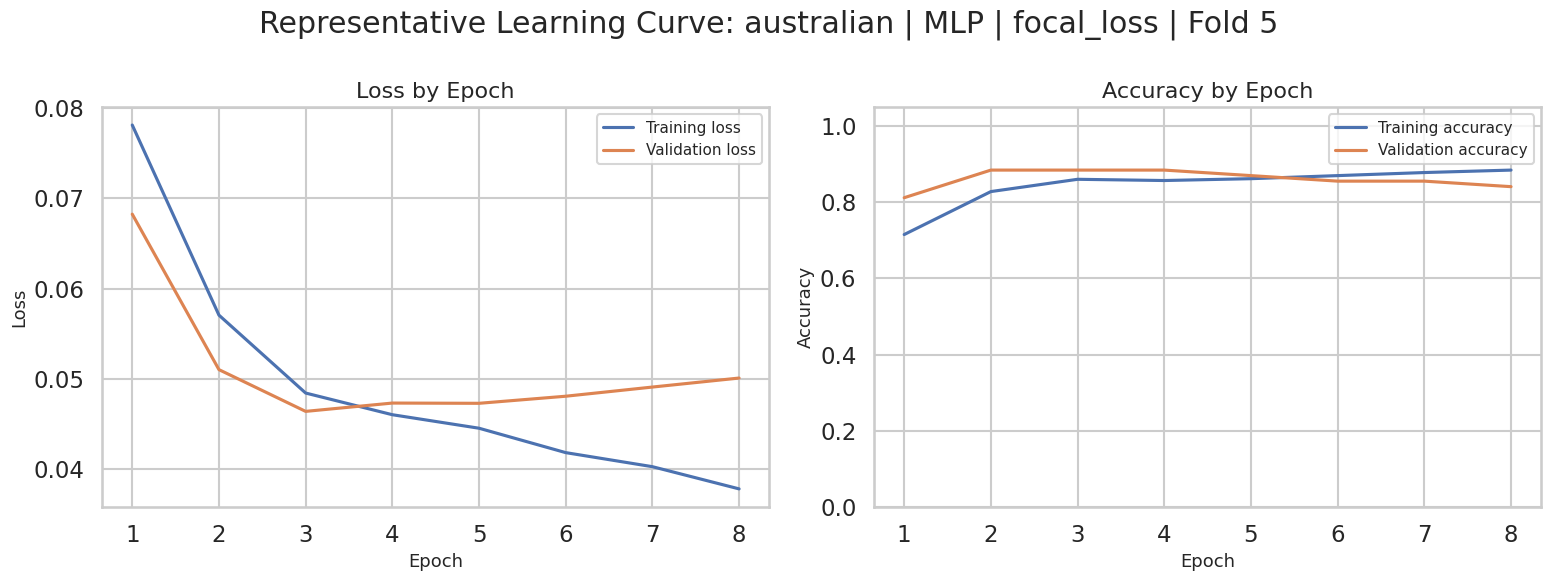

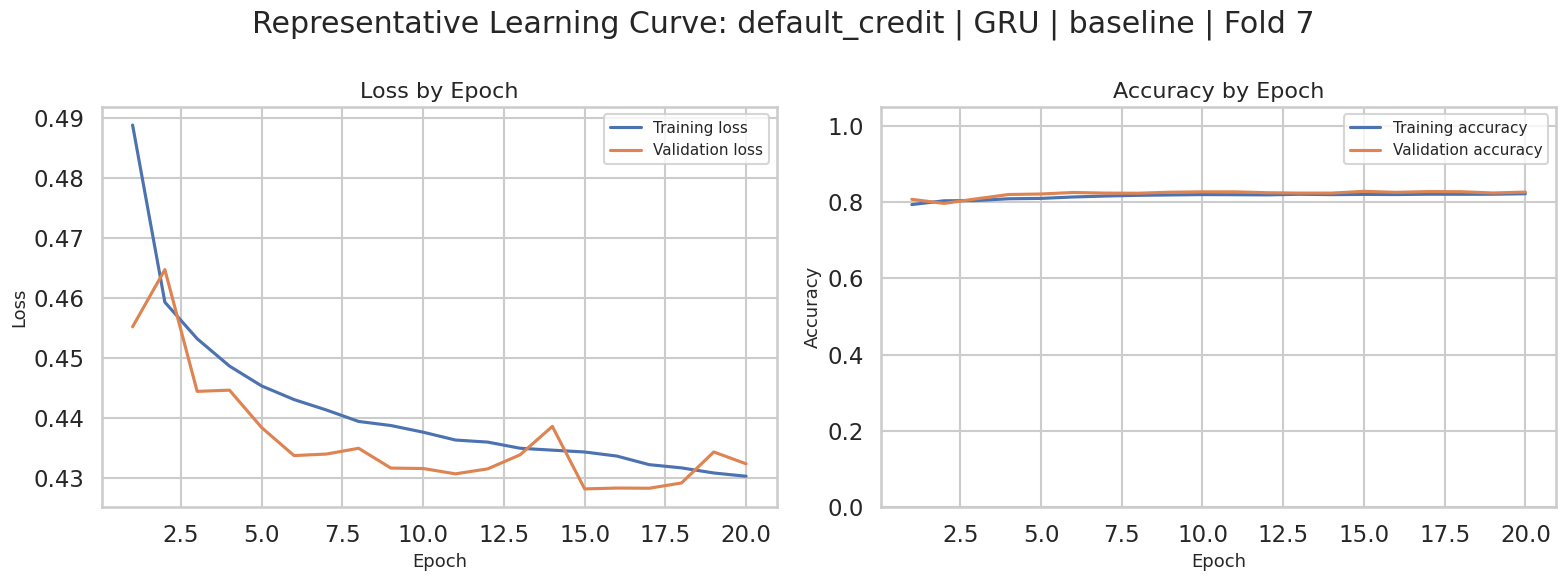

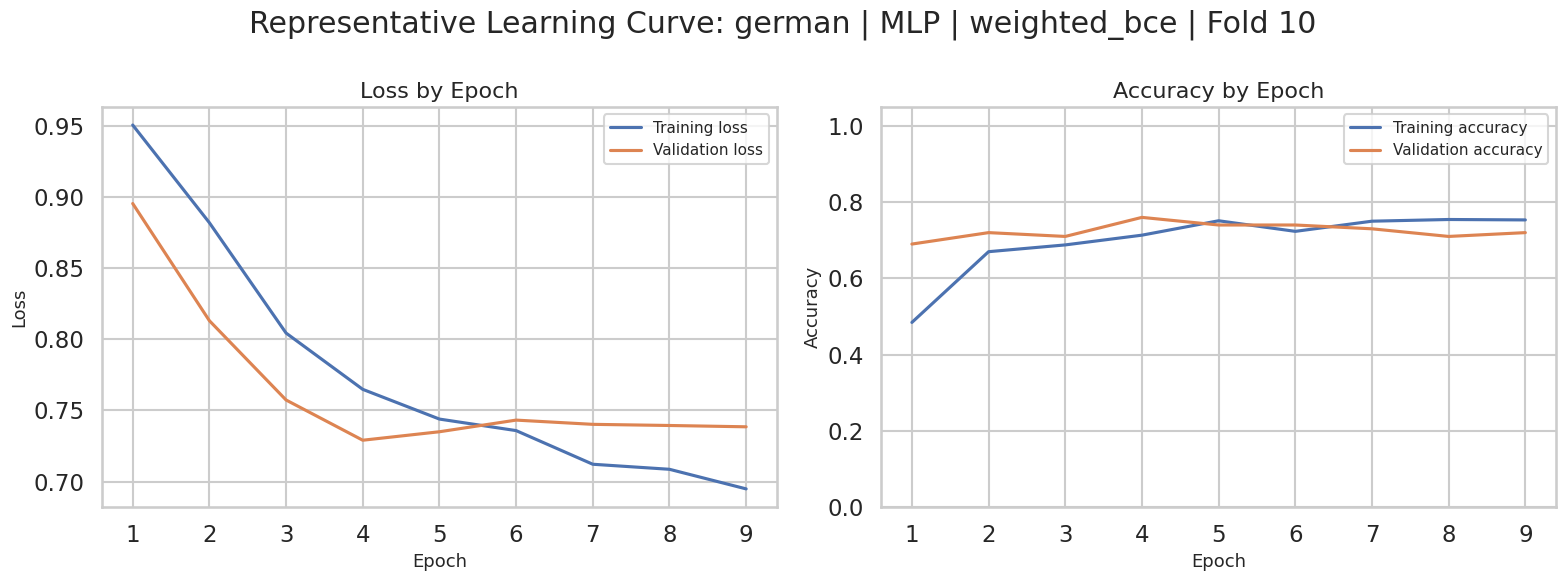

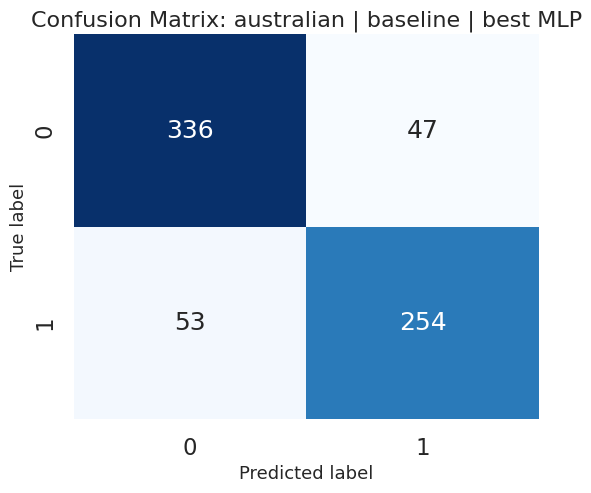

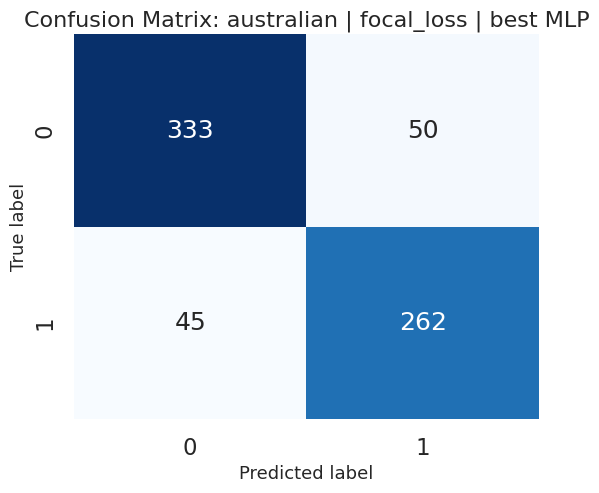

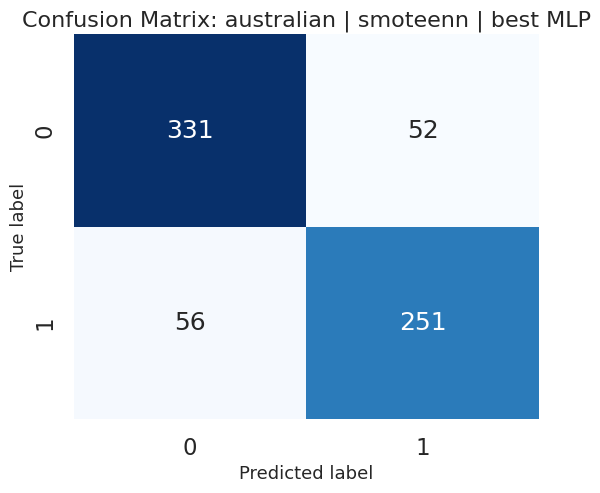

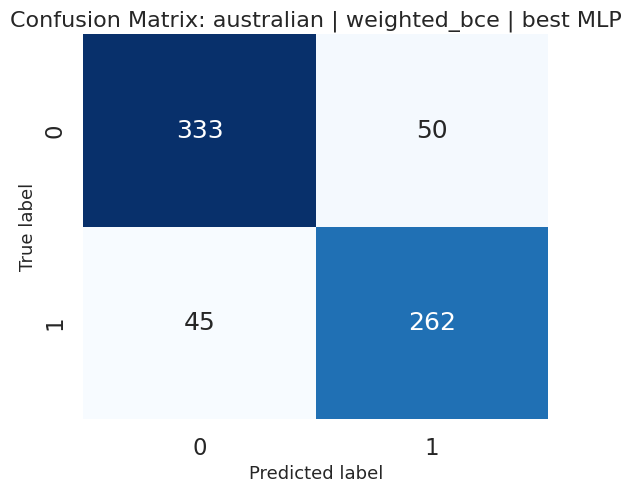

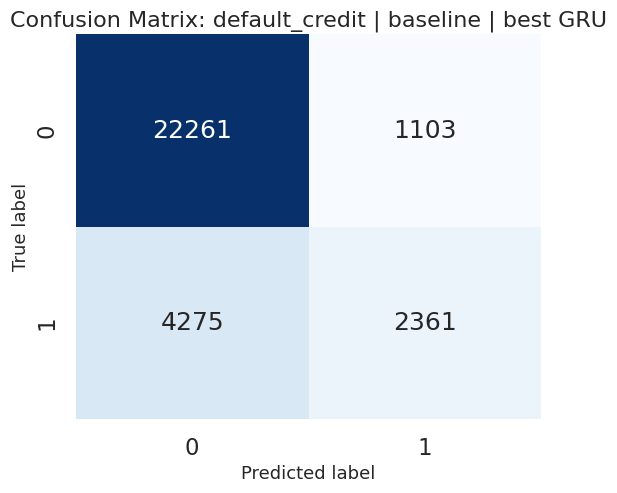

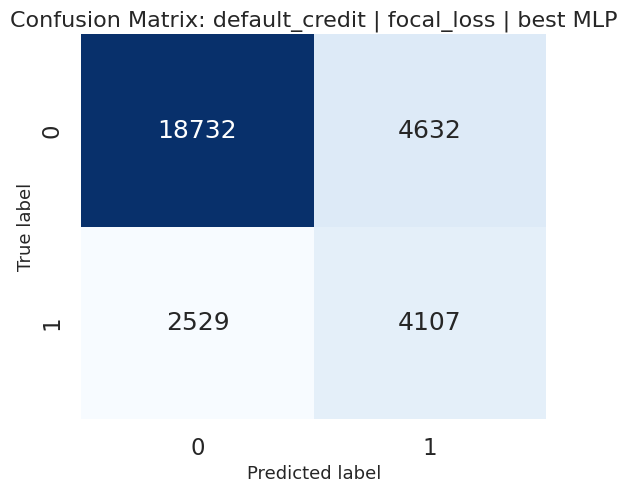

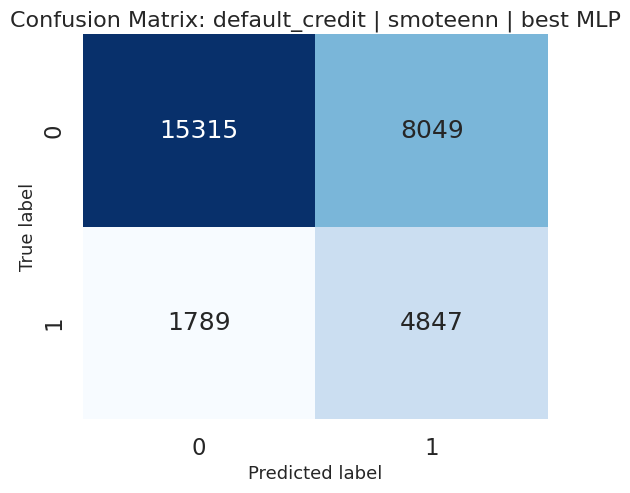

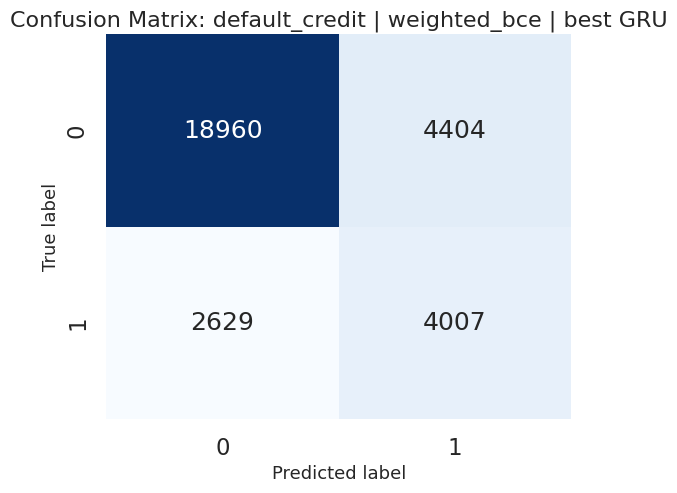

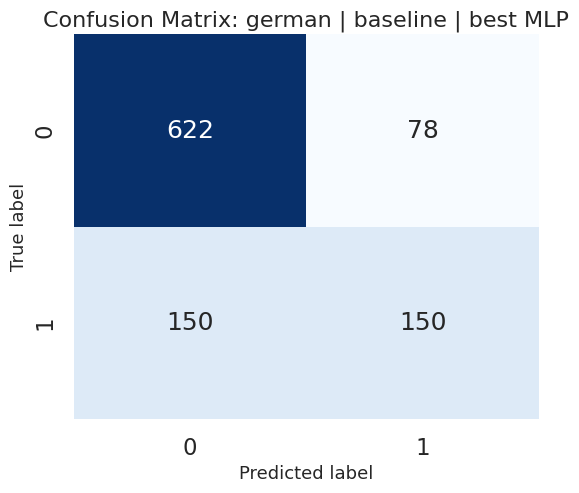

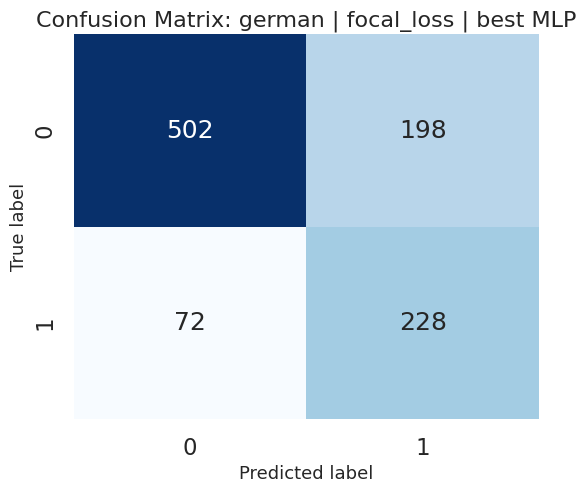

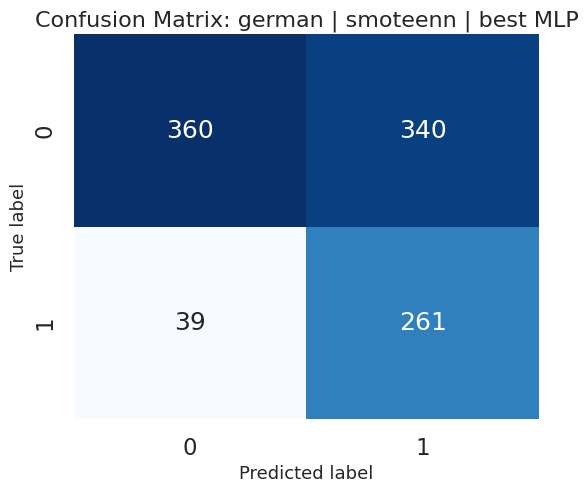

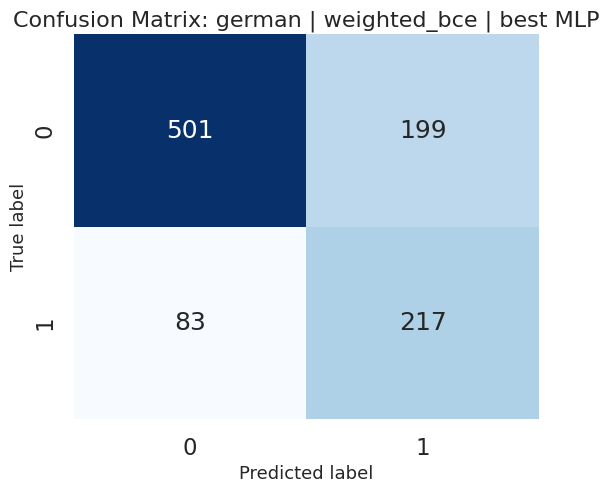

In [18]:
def best_config_per_dataset(metric_name: str = "pr_auc_mean") -> pd.DataFrame:
    best_rows = (
        aggregate_metrics_df.sort_values(
            ["dataset", metric_name, "balanced_accuracy_mean"],
            ascending=[True, False, False],
        )
        .groupby("dataset", as_index=False)
        .head(1)
        .reset_index(drop=True)
    )
    return best_rows


representative_rows = []
for _, aggregate_row in aggregate_metrics_df.iterrows():
    mask = (
        (successful_folds_df["dataset"] == aggregate_row["dataset"])
        & (successful_folds_df["model"] == aggregate_row["model"])
        & (successful_folds_df["condition"] == aggregate_row["condition"])
    )
    fold_subset = successful_folds_df.loc[mask, ["fold_id", "pr_auc", "history_path"]].copy()
    if fold_subset.empty:
        continue
    median_pr_auc = fold_subset["pr_auc"].median()
    fold_subset["distance_to_median"] = (fold_subset["pr_auc"] - median_pr_auc).abs()
    representative = fold_subset.sort_values(["distance_to_median", "fold_id"]).iloc[0]
    representative_rows.append(
        {
            "dataset": aggregate_row["dataset"],
            "model": aggregate_row["model"],
            "condition": aggregate_row["condition"],
            "fold_id": int(representative["fold_id"]),
            "history_path": representative["history_path"],
        }
    )

representative_folds_df = pd.DataFrame(representative_rows)
representative_folds_df.to_csv(OUTPUT_DIRS["tables"] / "representative_folds.csv", index=False)


def render_metric_bar(metric_name: str, filename: str) -> None:
    fig, ax = plt.subplots(figsize=(16, 7))
    plot_df = aggregate_metrics_df.copy()
    plot_df["dataset_model"] = plot_df["dataset"] + " | " + plot_df["model"].str.upper()
    sns.barplot(
        data=plot_df,
        x="dataset_model",
        y=f"{metric_name}_mean",
        hue="condition",
        ax=ax,
    )
    ax.set_title(f"Mean {metric_name.replace('_', ' ').title()} by Dataset, Model, and Condition")
    ax.set_xlabel("Dataset and Model")
    ax.set_ylabel(metric_name.replace("_", " ").title())
    ax.tick_params(axis="x", rotation=25)
    save_figure(fig, filename)
    plt.show()


for metric_name, filename in [
    ("accuracy", "mean_accuracy_comparison"),
    ("pr_auc", "mean_pr_auc_comparison"),
    ("f1", "mean_f1_comparison"),
    ("balanced_accuracy", "mean_balanced_accuracy_comparison"),
]:
    render_metric_bar(metric_name, filename)

heatmap_df = aggregate_metrics_df.pivot_table(
    index=["dataset", "model"],
    columns="condition",
    values="pr_auc_mean",
)
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(heatmap_df, annot=True, fmt=".3f", cmap="mako", ax=ax)
ax.set_title("Aggregate PR-AUC Heatmap")
save_figure(fig, "aggregate_performance_heatmap")
plt.show()

for _, row in representative_folds_df.merge(best_config_per_dataset(), on=["dataset", "model", "condition"], how="inner").iterrows():
    history_df = pd.read_csv(row["history_path"])
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)
    axes[0].plot(history_df["epoch"], history_df["train_loss"], label="Training loss")
    axes[0].plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss by Epoch")
    axes[0].legend()

    if {"train_accuracy", "val_accuracy"}.issubset(history_df.columns):
        axes[1].plot(history_df["epoch"], history_df["train_accuracy"], label="Training accuracy")
        axes[1].plot(history_df["epoch"], history_df["val_accuracy"], label="Validation accuracy")
        axes[1].set_xlabel("Epoch")
        axes[1].set_ylabel("Accuracy")
        axes[1].set_ylim(0.0, 1.05)
        axes[1].set_title("Accuracy by Epoch")
        axes[1].legend()
    else:
        axes[1].text(
            0.5,
            0.5,
            "Re-run the experiment section to generate training and validation accuracy histories.",
            ha="center",
            va="center",
            wrap=True,
        )
        axes[1].set_axis_off()

    fig.suptitle(
        f"Representative Learning Curve: {row['dataset']} | {row['model'].upper()} | {row['condition']} | Fold {int(row['fold_id'])}"
    )
    fig.tight_layout()
    save_figure(fig, f"learning_curve_{row['dataset']}_{row['model']}_{row['condition']}")
    plt.show()

best_per_dataset_condition = (
    aggregate_metrics_df.sort_values(
        ["dataset", "condition", "pr_auc_mean", "balanced_accuracy_mean"],
        ascending=[True, True, False, False],
    )
    .groupby(["dataset", "condition"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

for _, best_row in best_per_dataset_condition.iterrows():
    prediction_frames = []
    matching_rows = successful_folds_df[
        (successful_folds_df["dataset"] == best_row["dataset"])
        & (successful_folds_df["model"] == best_row["model"])
        & (successful_folds_df["condition"] == best_row["condition"])
    ]
    for prediction_path in matching_rows["prediction_path"]:
        prediction_frames.append(pd.read_csv(prediction_path))
    oof_df = pd.concat(prediction_frames, ignore_index=True)
    cm = confusion_matrix(oof_df["y_true"], oof_df["y_pred"], labels=[0, 1])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(
        f"Confusion Matrix: {best_row['dataset']} | {best_row['condition']} | best {best_row['model'].upper()}"
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    save_figure(fig, f"confusion_matrix_{best_row['dataset']}_{best_row['condition']}")
    plt.show()


## ***Section 17: SHAP Explainability***

SHAP is included to support model interpretation, but we avoid overstating what these explanations mean. We restrict SHAP to the best-performing MLP condition per dataset because fully recurrent explanations are more fragile, more expensive, and less defensible in this static tabular setting. We treat SHAP as a descriptive attribution method rather than a causal identification tool.

The next cell selects the best MLP configuration per dataset, reconstructs its representative fold, and attempts `shap.DeepExplainer`. If that fails, the notebook logs the failure and falls back to `KernelExplainer`, and if necessary to permutation-style importance. The expected outputs are SHAP summary figures, bar plots, and a top-features table saved to disk.


In [19]:
def sigmoid_predict(model: nn.Module, feature_matrix: np.ndarray, model_name: str) -> np.ndarray:
    dataset = TabularDataset(feature_matrix, np.zeros(len(feature_matrix), dtype=np.int64), model_name=model_name)
    loader = DataLoader(dataset, batch_size=256, shuffle=False)
    probabilities = predict_proba(model, loader)
    return probabilities.reshape(-1, 1)


def normalize_shap_values_array(shap_values: Any, feature_count: int) -> np.ndarray:
    shap_array = np.asarray(shap_values)
    shap_array = np.squeeze(shap_array)

    if shap_array.ndim == 0:
        raise ValueError("SHAP returned a scalar instead of feature attributions.")

    if shap_array.ndim == 1:
        if shap_array.shape[0] != feature_count:
            raise ValueError(f"Unexpected 1D SHAP shape {shap_array.shape} for {feature_count} features.")
        return shap_array.reshape(1, -1)

    if shap_array.ndim == 2:
        if shap_array.shape[1] == feature_count:
            return shap_array
        if shap_array.shape[0] == feature_count:
            return shap_array.T

    feature_axes = [axis for axis, size in enumerate(shap_array.shape) if size == feature_count]
    if not feature_axes:
        raise ValueError(f"Could not find a feature axis in SHAP output with shape {shap_array.shape}.")

    feature_axis = feature_axes[-1]
    shap_array = np.moveaxis(shap_array, feature_axis, -1)
    if shap_array.ndim > 2:
        leading_axes = tuple(range(shap_array.ndim - 2))
        shap_array = shap_array.mean(axis=leading_axes)

    if shap_array.ndim == 1:
        shap_array = shap_array.reshape(1, -1)

    if shap_array.ndim != 2 or shap_array.shape[1] != feature_count:
        raise ValueError(f"Unable to normalize SHAP values with final shape {shap_array.shape}.")

    return shap_array


shap_rows = []
mlp_aggregate = aggregate_metrics_df.query("model == 'mlp'").copy()
best_mlp_per_dataset = (
    mlp_aggregate.sort_values(["dataset", "pr_auc_mean", "balanced_accuracy_mean"], ascending=[True, False, False])
    .groupby("dataset", as_index=False)
    .head(1)
    .reset_index(drop=True)
)

for _, best_row in best_mlp_per_dataset.iterrows():
    dataset_name = best_row["dataset"]
    condition = best_row["condition"]
    fold_subset = successful_folds_df[
        (successful_folds_df["dataset"] == dataset_name)
        & (successful_folds_df["model"] == "mlp")
        & (successful_folds_df["condition"] == condition)
    ].copy()
    fold_subset["distance_to_median"] = (fold_subset["pr_auc"] - fold_subset["pr_auc"].median()).abs()
    selected_fold = fold_subset.sort_values(["distance_to_median", "fold_id"]).iloc[0]

    split_indices = rebuild_splits(dataset_name, DATASETS[dataset_name]["y"])
    train_idx, val_idx = split_indices[int(selected_fold["fold_id"]) - 1]
    fold_data = get_preprocessed_fold_data(dataset_name, int(selected_fold["fold_id"]), train_idx, val_idx)
    X_train_processed = fold_data["X_train_processed"]
    X_val_processed = fold_data["X_val_processed"]
    feature_names = fold_data["feature_names"]

    checkpoint = torch.load(selected_fold["checkpoint_path"], map_location=DEVICE)
    model = MLPClassifier(
        input_dim=int(checkpoint["input_dim"]),
        hidden_units=CONFIG["model_hyperparameters"]["mlp"]["hidden_units"],
        dropout=CONFIG["model_hyperparameters"]["mlp"]["dropout"],
    ).to(DEVICE)
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()

    rng = np.random.default_rng(CONFIG["seed"])
    background_size = min(CONFIG["effective_shap_background_size"], len(X_train_processed))
    explain_size = min(CONFIG["effective_shap_explain_size"], len(X_val_processed))
    background_idx = rng.choice(len(X_train_processed), size=background_size, replace=False)
    explain_idx = rng.choice(len(X_val_processed), size=explain_size, replace=False)

    background = X_train_processed[background_idx]
    explain_data = X_val_processed[explain_idx]

    metadata = {
        "dataset": dataset_name,
        "model": "mlp",
        "condition": condition,
        "fold_id": int(selected_fold["fold_id"]),
        "explainer": None,
        "status": "pending",
    }

    shap_values_array = None
    try:
        explainer = shap.DeepExplainer(
            model,
            torch.tensor(background, dtype=torch.float32, device=DEVICE),
        )
        shap_values = explainer.shap_values(torch.tensor(explain_data, dtype=torch.float32, device=DEVICE))
        shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values
        metadata["explainer"] = "DeepExplainer"
        metadata["status"] = "success"
    except Exception as deep_exc:
        logger.warning(f"DeepExplainer failed for {dataset_name}: {deep_exc}")
        try:
            kernel_background = shap.sample(background, min(50, len(background)), random_state=CONFIG["seed"])
            explainer = shap.KernelExplainer(
                lambda array: sigmoid_predict(model, np.asarray(array, dtype=np.float32), model_name="mlp"),
                kernel_background,
            )
            shap_values = explainer.shap_values(explain_data, nsamples=CONFIG["kernel_shap_nsamples"])
            shap_values_array = shap_values[0] if isinstance(shap_values, list) else shap_values
            metadata["explainer"] = "KernelExplainer"
            metadata["status"] = "success"
        except Exception as kernel_exc:
            logger.warning(f"KernelExplainer failed for {dataset_name}: {kernel_exc}")
            baseline_prob = sigmoid_predict(model, explain_data, model_name="mlp").reshape(-1)
            importance_rows = []
            for feature_idx, feature_name in enumerate(feature_names):
                perturbed = explain_data.copy()
                perturbed[:, feature_idx] = np.mean(background[:, feature_idx])
                perturbed_prob = sigmoid_predict(model, perturbed, model_name="mlp").reshape(-1)
                importance_rows.append(
                    {
                        "feature": feature_name,
                        "mean_abs_importance": float(np.mean(np.abs(baseline_prob - perturbed_prob))),
                    }
                )
            importance_df = pd.DataFrame(importance_rows).sort_values("mean_abs_importance", ascending=False)
            importance_df.to_csv(OUTPUT_DIRS["shap"] / f"{dataset_name}_permutation_importance.csv", index=False)
            fig, ax = plt.subplots(figsize=(10, 6))
            sns.barplot(data=importance_df.head(15), x="mean_abs_importance", y="feature", ax=ax, palette="crest")
            ax.set_title(f"Permutation-style Importance Fallback: {dataset_name}")
            save_figure(fig, f"{dataset_name}_permutation_importance", directory=OUTPUT_DIRS["shap"])
            plt.show()
            metadata["explainer"] = "PermutationFallback"
            metadata["status"] = "fallback"
            metadata["fallback_reason"] = str(kernel_exc)
            save_json(metadata, OUTPUT_DIRS["shap"] / f"{dataset_name}_explanation_metadata.json")
            for _, importance_row in importance_df.head(15).iterrows():
                shap_rows.append(
                    {
                        "dataset": dataset_name,
                        "condition": condition,
                        "feature": importance_row["feature"],
                        "importance": importance_row["mean_abs_importance"],
                        "explainer": metadata["explainer"],
                    }
                )
            continue

    raw_shap_shape = tuple(np.asarray(shap_values_array).shape)
    shap_values_array = normalize_shap_values_array(shap_values_array, feature_count=len(feature_names))
    metadata["raw_shap_shape"] = raw_shap_shape
    metadata["normalized_shap_shape"] = tuple(shap_values_array.shape)
    mean_abs_shap = np.mean(np.abs(shap_values_array), axis=0)
    shap_df = pd.DataFrame({"feature": feature_names, "mean_abs_shap": mean_abs_shap}).sort_values(
        "mean_abs_shap",
        ascending=False,
    )
    shap_df.to_csv(OUTPUT_DIRS["shap"] / f"{dataset_name}_shap_values.csv", index=False)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_array, explain_data, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary Plot: {dataset_name} | {condition}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRS["shap"] / f"{dataset_name}_shap_summary.png")
    plt.close()

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values_array, explain_data, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Feature Importance: {dataset_name} | {condition}")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIRS["shap"] / f"{dataset_name}_shap_bar.png")
    plt.close()

    metadata["explainer"] = metadata["explainer"] or "Unknown"
    metadata["status"] = metadata["status"] or "success"
    save_json(metadata, OUTPUT_DIRS["shap"] / f"{dataset_name}_explanation_metadata.json")

    for _, shap_row in shap_df.head(15).iterrows():
        shap_rows.append(
            {
                "dataset": dataset_name,
                "condition": condition,
                "feature": shap_row["feature"],
                "importance": shap_row["mean_abs_shap"],
                "explainer": metadata["explainer"],
            }
        )

shap_top_features_df = pd.DataFrame(shap_rows).sort_values(["dataset", "importance"], ascending=[True, False])
shap_top_features_df.to_csv(OUTPUT_DIRS["tables"] / "shap_top_features.csv", index=False)
display(shap_top_features_df.head(15))


2026-04-25 15:51:35,075 | WARNING | DeepExplainer failed for australian: tuple index out of range


  0%|          | 0/64 [00:00<?, ?it/s]

2026-04-25 15:51:37,871 | WARNING | DeepExplainer failed for default_credit: tuple index out of range


  0%|          | 0/64 [00:00<?, ?it/s]

2026-04-25 15:51:40,277 | WARNING | DeepExplainer failed for german: tuple index out of range


  0%|          | 0/64 [00:00<?, ?it/s]

,dataset,condition,feature,importance,explainer
0,australian,focal_loss,A4,0.043281,KernelExplainer
1,australian,focal_loss,A7_1,0.039307,KernelExplainer
2,australian,focal_loss,A7_0,0.034694,KernelExplainer
3,australian,focal_loss,A9,0.029348,KernelExplainer
4,australian,focal_loss,A6,0.015241,KernelExplainer
5,australian,focal_loss,A8_0,0.009841,KernelExplainer
6,australian,focal_loss,A8_1,0.009688,KernelExplainer
7,australian,focal_loss,A13,0.007882,KernelExplainer
8,australian,focal_loss,A1,0.007204,KernelExplainer
9,australian,focal_loss,A12,0.006037,KernelExplainer


## ***Section 18: Error Analysis***

Aggregate metrics can conceal systematic failure modes. We therefore inspect false positives and false negatives for the best-performing model on each dataset, then compare the distribution of influential features across error groups and correct predictions. This analysis is descriptive rather than causal, but it helps identify which regions of feature space remain difficult for the model to classify reliably.

The outputs of the next cell are an error-analysis table and diagnostic feature plots for the most influential features available from the explainability section.


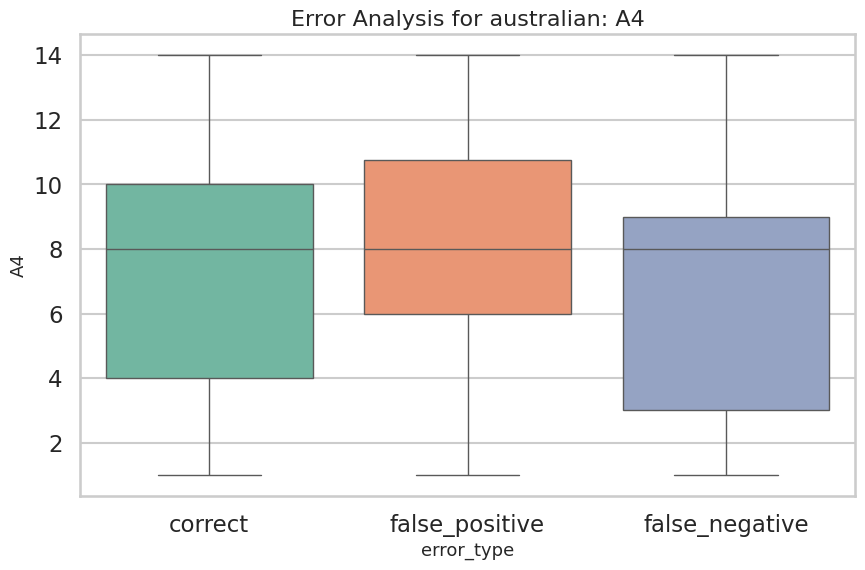

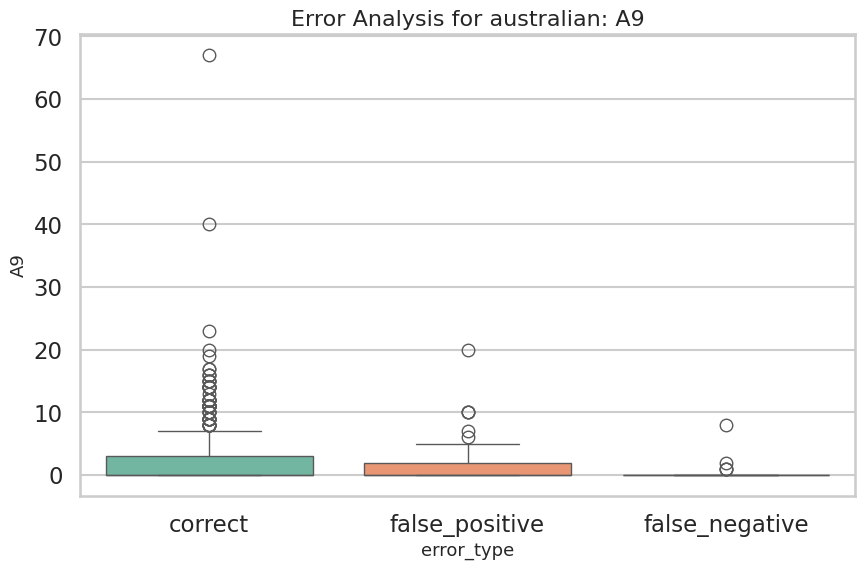

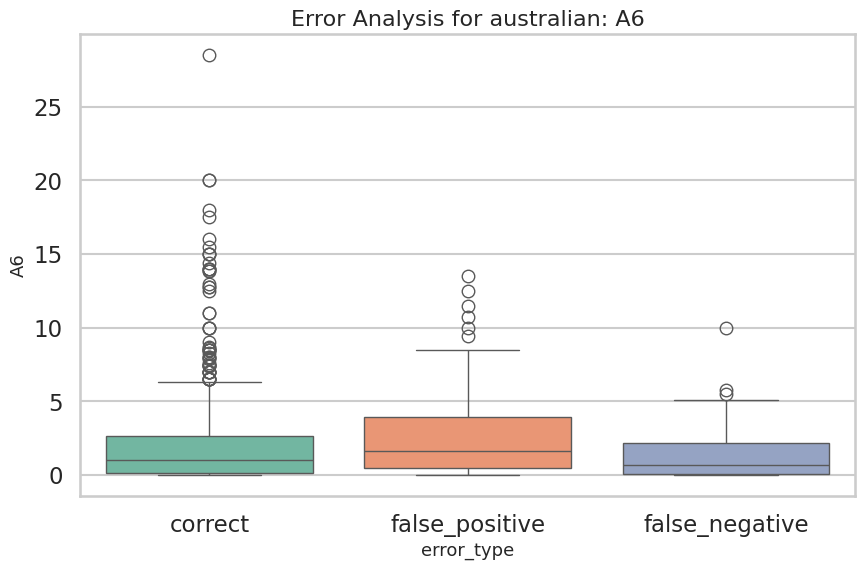

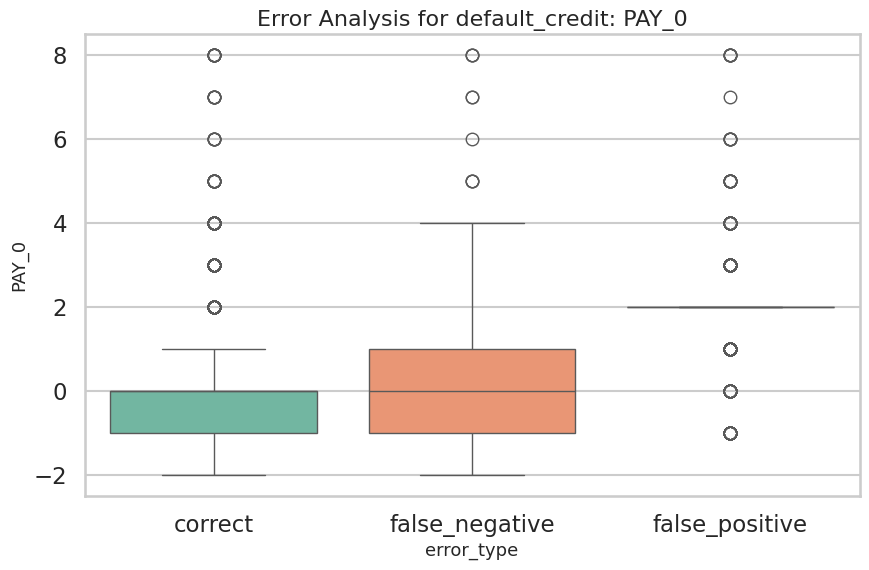

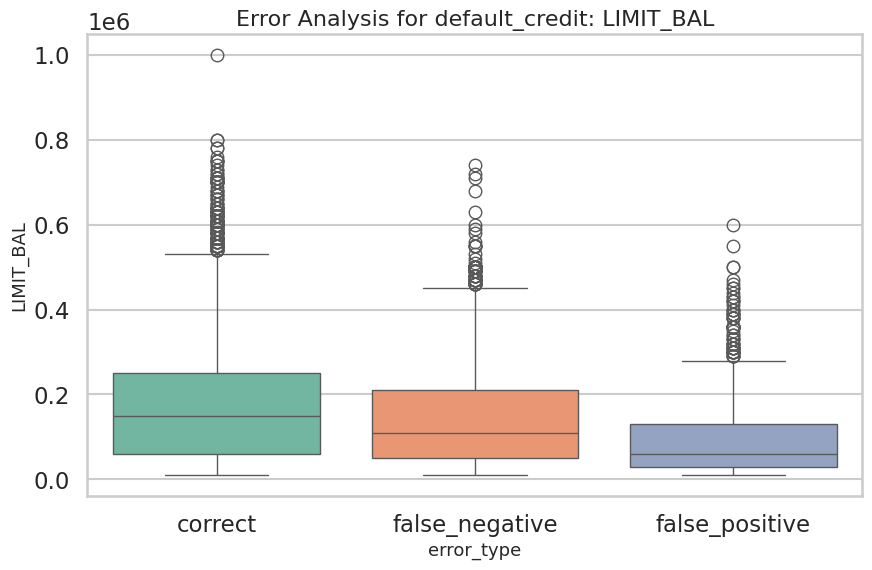

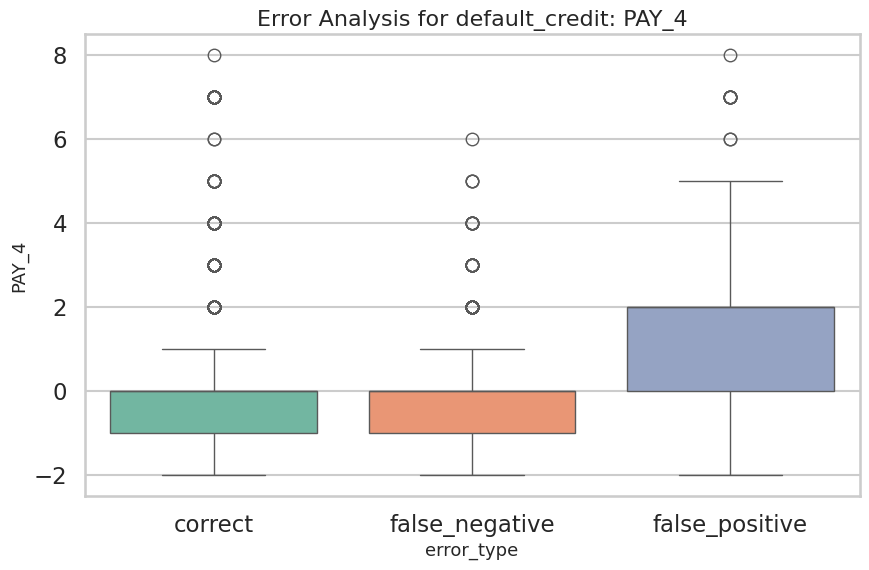

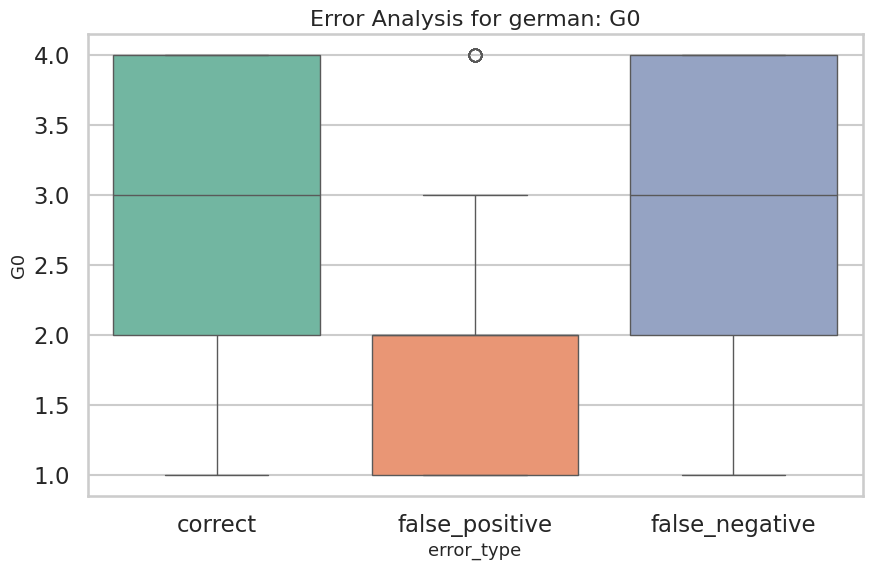

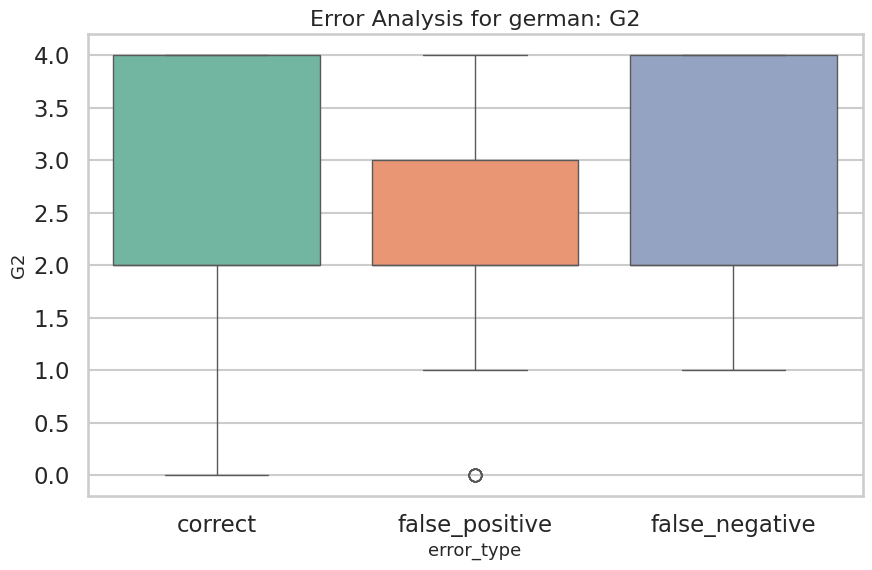

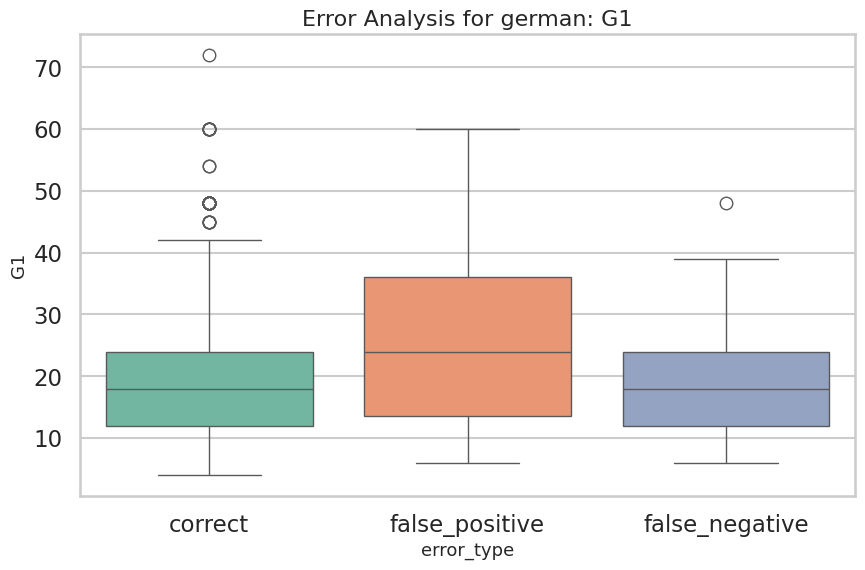

,dataset,model,condition,error_type,count,rate
0,australian,mlp,focal_loss,correct,595,0.862319
1,australian,mlp,focal_loss,false_negative,45,0.065217
2,australian,mlp,focal_loss,false_positive,50,0.072464
3,default_credit,gru,baseline,correct,24622,0.820733
4,default_credit,gru,baseline,false_negative,4275,0.142500
5,default_credit,gru,baseline,false_positive,1103,0.036767
6,german,mlp,weighted_bce,correct,718,0.718000
7,german,mlp,weighted_bce,false_negative,83,0.083000
8,german,mlp,weighted_bce,false_positive,199,0.199000


In [20]:
best_models_df = best_config_per_dataset(metric_name="pr_auc_mean").copy()
best_models_df.to_csv(OUTPUT_DIRS["tables"] / "best_models.csv", index=False)

error_analysis_rows = []
top_shap_lookup = (
    shap_top_features_df.groupby("dataset")["feature"].apply(lambda values: list(values.head(5))).to_dict()
    if not shap_top_features_df.empty
    else {}
)

for _, best_row in best_models_df.iterrows():
    dataset_name = best_row["dataset"]
    model_name = best_row["model"]
    condition = best_row["condition"]
    matching_rows = successful_folds_df[
        (successful_folds_df["dataset"] == dataset_name)
        & (successful_folds_df["model"] == model_name)
        & (successful_folds_df["condition"] == condition)
    ]
    prediction_frames = [pd.read_csv(path) for path in matching_rows["prediction_path"]]
    oof_df = pd.concat(prediction_frames, ignore_index=True).sort_values("row_index").reset_index(drop=True)
    raw_features = DATASETS[dataset_name]["X"].reset_index(drop=True).iloc[oof_df["row_index"]].reset_index(drop=True)

    oof_df["error_type"] = np.select(
        [
            (oof_df["y_true"] == 1) & (oof_df["y_pred"] == 0),
            (oof_df["y_true"] == 0) & (oof_df["y_pred"] == 1),
        ],
        ["false_negative", "false_positive"],
        default="correct",
    )

    for error_type, subset in oof_df.groupby("error_type"):
        row = {
            "dataset": dataset_name,
            "model": model_name,
            "condition": condition,
            "error_type": error_type,
            "count": int(len(subset)),
            "rate": float(len(subset) / len(oof_df)),
        }
        error_analysis_rows.append(row)

    feature_candidates = [feature for feature in top_shap_lookup.get(dataset_name, []) if feature in raw_features.columns]
    for feature_name in feature_candidates[:3]:
        plot_df = pd.concat([raw_features[[feature_name]], oof_df[["error_type"]]], axis=1)
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.boxplot(data=plot_df, x="error_type", y=feature_name, ax=ax, palette="Set2")
        ax.set_title(f"Error Analysis for {dataset_name}: {feature_name}")
        save_figure(fig, f"error_analysis_{dataset_name}_{feature_name}", directory=OUTPUT_DIRS["plots"])
        plt.show()

error_analysis_df = pd.DataFrame(error_analysis_rows)
error_analysis_df.to_csv(OUTPUT_DIRS["tables"] / "error_analysis.csv", index=False)
display(error_analysis_df)


## ***Section 19: Final Research Tables for Report***

The goal of this section is to transform the notebook outputs into publication-ready tables that can be inserted directly into the written assignment. Because every table is derived from saved artifacts rather than manual editing, the report remains synchronized with the executed experiment state. We export each table in CSV format, and where practical we also create Markdown and LaTeX renderings for easier reuse in the final report.

The output of the next cell is a set of report tables written to disk. Interpretation belongs primarily in the final written report, but we also display a concise preview for verification.


In [26]:
experimental_design_table = pd.DataFrame(
    [
        {"component": "Datasets", "details": ", ".join(CONFIG["datasets"])},
        {"component": "Models", "details": ", ".join(CONFIG["models"])},
        {"component": "Conditions", "details": ", ".join(CONFIG["conditions"])},
        {"component": "Folds", "details": CONFIG["n_splits"]},
        {"component": "Epochs", "details": CONFIG["num_epochs"]},
        {"component": "Early stopping patience", "details": CONFIG["early_stopping_patience"]},
    ]
)
experimental_design_table.to_csv(OUTPUT_DIRS["tables"] / "experimental_design_table.csv", index=False)

publication_tables = {
    "dataset_summary": dataset_summary_df,
    "experimental_design": experimental_design_table,
    "paper_metrics_table": paper_metrics_table,
    "extended_metrics_table": extended_metrics_table,
    "best_models": best_models_df,
    "statistical_significance_table": statistical_tests_df,
    "shap_top_features": shap_top_features_df,
}

for table_name, table_df in publication_tables.items():
    rounded_df = table_df.copy()
    numeric_columns = rounded_df.select_dtypes(include=[np.number]).columns
    rounded_df[numeric_columns] = rounded_df[numeric_columns].round(4)
    rounded_df.to_csv(OUTPUT_DIRS["tables"] / f"{table_name}.csv", index=False)
    try:
        (OUTPUT_DIRS["tables"] / f"{table_name}.md").write_text(rounded_df.to_markdown(index=False), encoding="utf-8")
    except Exception as exc:
        logger.warning(f"Markdown export failed for {table_name}: {exc}")
    try:
        (OUTPUT_DIRS["tables"] / f"{table_name}.tex").write_text(rounded_df.to_latex(index=False), encoding="utf-8")
    except Exception as exc:
        logger.warning(f"LaTeX export failed for {table_name}: {exc}")

display(best_models_df)


,dataset,model,condition,accuracy_mean,accuracy_std,accuracy_median,sensitivity_mean,sensitivity_std,specificity_mean,specificity_std,...,f1_std,roc_auc_mean,roc_auc_std,pr_auc_mean,pr_auc_std,balanced_accuracy_mean,balanced_accuracy_std,val_loss_mean,runtime_seconds_mean,fold_count
0,australian,mlp,focal_loss,0.862319,0.057668,0.876812,0.854516,0.119838,0.869636,0.062660,...,0.072042,0.935150,0.040666,0.921342,0.037571,0.862076,0.062044,0.042347,2.494461,10
1,default_credit,gru,baseline,0.820733,0.006146,0.820500,0.355791,0.019915,0.952790,0.005481,...,0.020749,0.773796,0.011141,0.552457,0.020182,0.654290,0.010276,0.431643,92.605706,10
2,german,mlp,weighted_bce,0.718000,0.053292,0.720000,0.723333,0.070361,0.715714,0.057715,...,0.063668,0.803238,0.039581,0.645444,0.069093,0.719524,0.054569,0.748518,3.169164,10


## ***Section 20: Automated Report Summary JSON***

The report summary JSON acts as a compact machine-readable bridge between the notebook and the written assignment. It collects the research question, hypothesis, dataset summaries, best models, statistical findings, limitations, and artifact paths in one place so that the narrative can be drafted from executed results rather than from memory.

The next cell generates this JSON file. The expected output is a preview of the structured summary and a saved `report_summary.json` artifact.


In [27]:
loss_based_vs_smote = (
    aggregate_metrics_df.assign(is_loss_based=lambda df: df["condition"].isin(["weighted_bce", "focal_loss"]))
    .groupby(["dataset", "is_loss_based"])["pr_auc_mean"]
    .max()
    .reset_index()
)

key_findings = []
for dataset_name in CONFIG["datasets"]:
    dataset_best = best_models_df[best_models_df["dataset"] == dataset_name].iloc[0]
    key_findings.append(
        f"For {dataset_name}, the best aggregate configuration was {dataset_best['model'].upper()} with {dataset_best['condition']} "
        f"(mean PR-AUC={dataset_best['pr_auc_mean']:.4f}, mean balanced accuracy={dataset_best['balanced_accuracy_mean']:.4f})."
    )

smote_wins = 0
loss_wins = 0
for dataset_name in CONFIG["datasets"]:
    dataset_agg = aggregate_metrics_df[aggregate_metrics_df["dataset"] == dataset_name]
    smote_score = dataset_agg[dataset_agg["condition"] == "smoteenn"]["pr_auc_mean"].max()
    loss_score = dataset_agg[dataset_agg["condition"].isin(["weighted_bce", "focal_loss"])]["pr_auc_mean"].max()
    if pd.notna(smote_score) and pd.notna(loss_score):
        smote_wins += int(smote_score > loss_score)
        loss_wins += int(loss_score >= smote_score)

key_findings.append(
    f"Across datasets, loss-based conditions matched or outperformed SMOTE-ENN on PR-AUC in {loss_wins} of {len(CONFIG['datasets'])} cases, "
    f"whereas SMOTE-ENN led in {smote_wins} cases."
)

report_summary = {
    "research_question": "Does SMOTE-ENN consistently improve deep learning credit-risk prediction across datasets, or do loss-based imbalance-handling methods generalize better by preserving the original data distribution?",
    "hypothesis": "Loss-based imbalance handling, especially Weighted BCE and Focal Loss, will provide more stable generalization than SMOTE-ENN because it does not synthetically alter the training distribution.",
    "dataset_summaries": dataset_summary_df.to_dict(orient="records"),
    "best_models": best_models_df.to_dict(orient="records"),
    "key_findings": key_findings,
    "statistical_test_summary": statistical_tests_df.head(20).to_dict(orient="records"),
    "limitations": [
        "LSTM and GRU architectures are applied to static tabular data through a feature-as-sequence representation that reproduces the architectural comparison but does not create true temporal structure.",
        "The Australian and German datasets are relatively small, which increases fold variance and reduces the stability of inferential claims.",
        "SHAP approximations depend on explainer compatibility and sample size, especially when fallback explainers are required.",
        "Runtime constraints may still influence the number of epochs effectively used due to early stopping.",
    ],
    "artifact_paths": {name: str(path) for name, path in OUTPUT_DIRS.items()},
}

save_json(report_summary, OUTPUT_DIRS["root"] / "report_summary.json")
print(pd.Series(report_summary))


research_question           Does SMOTE-ENN consistently improve deep learn...
hypothesis                  Loss-based imbalance handling, especially Weig...
dataset_summaries           [{'dataset': 'Australian Credit Approval', 'ro...
best_models                 [{'dataset': 'australian', 'model': 'mlp', 'co...
key_findings                [For australian, the best aggregate configurat...
statistical_test_summary    [{'metric': 'accuracy', 'n_pairs': 10, 'left_m...
limitations                 [LSTM and GRU architectures are applied to sta...
artifact_paths              {'root': '/kaggle/working/assignment3_outputs'...
dtype: object


## ***Section 21: Reproducibility Checklist***

The final reproducibility check converts the assignment requirements into explicit validation statements. This is useful both for our own quality assurance and for demonstrating that the notebook has actually produced the promised artifacts. The checklist does not prove scientific validity on its own, but it does guard against silent omissions such as missing SHAP outputs, incomplete fold runs, or unsaved summary tables.

The expected output of the next cell is a checklist table with Boolean pass indicators and short detail strings.


In [23]:
expected_experiments = len(CONFIG["datasets"]) * len(CONFIG["models"]) * len(CONFIG["conditions"]) * CONFIG["n_splits"]
shap_files = list(OUTPUT_DIRS["shap"].glob("*.png")) + list(OUTPUT_DIRS["shap"].glob("*.csv")) + list(OUTPUT_DIRS["shap"].glob("*.json"))

checklist = pd.DataFrame(
    [
        {"item": "Seeds set", "passed": True, "details": CONFIG["seed"]},
        {"item": "Dataset files found", "passed": all(Path(bundle["path"]).exists() for bundle in DATASETS.values()), "details": DATASET_PATH_SUMMARY.to_dict(orient="records")},
        {"item": "All expected experiments completed", "passed": len(successful_folds_df) == expected_experiments, "details": f"{len(successful_folds_df)} / {expected_experiments} successful folds"},
        {"item": "Metrics saved", "passed": (OUTPUT_DIRS["metrics"] / "all_fold_metrics.csv").exists() and (OUTPUT_DIRS["metrics"] / "aggregate_metrics.csv").exists(), "details": "Master metric files present"},
        {"item": "Histories saved", "passed": (OUTPUT_DIRS["histories"] / "all_histories.json").exists(), "details": f"{len(list(OUTPUT_DIRS['histories'].glob('*_history.csv')))} fold histories"},
        {"item": "Plots saved", "passed": len(list(OUTPUT_DIRS["plots"].glob("*.png"))) > 0, "details": f"{len(list(OUTPUT_DIRS['plots'].glob('*')))} plot files"},
        {"item": "SHAP outputs saved or fallback documented", "passed": len(shap_files) > 0, "details": f"{len(shap_files)} SHAP/fallback files"},
        {"item": "Statistical tests saved", "passed": (OUTPUT_DIRS["metrics"] / "statistical_tests.csv").exists(), "details": "Wilcoxon and paired t-test table present"},
        {"item": "Final tables saved", "passed": (OUTPUT_DIRS["tables"] / "best_models.csv").exists(), "details": f"{len(list(OUTPUT_DIRS['tables'].glob('*')))} table files"},
    ]
)

display(checklist)


,item,passed,details
0,Seeds set,True,42
1,Dataset files found,True,"[{'dataset': 'Australian Credit Approval', 'pa..."
2,All expected experiments completed,True,360 / 360 successful folds
3,Metrics saved,True,Master metric files present
4,Histories saved,True,360 fold histories
5,Plots saved,True,60 plot files
6,SHAP outputs saved or fallback documented,True,12 SHAP/fallback files
7,Statistical tests saved,True,Wilcoxon and paired t-test table present
8,Final tables saved,True,29 table files


## ***Section 22: Final Notebook Discussion***

The final discussion synthesizes the experimental findings back into the assignment’s central research question. Rather than manually drafting the summary from memory, we generate a concise evidence-linked narrative from the actual aggregated outputs. This keeps the prose aligned with the executed experiment state and reduces the risk of overstating patterns that the metrics do not support.


In [24]:
condition_summary = (
    aggregate_metrics_df.groupby(["dataset", "condition"])["pr_auc_mean"]
    .max()
    .reset_index()
    .sort_values(["dataset", "pr_auc_mean"], ascending=[True, False])
)

discussion_lines = [
    "### Programmatic Discussion Summary",
    "",
    "We evaluate whether SMOTE-ENN improves generalization consistently relative to loss-based imbalance handling.",
    "",
]

for dataset_name in CONFIG["datasets"]:
    dataset_conditions = condition_summary[condition_summary["dataset"] == dataset_name]
    best_condition_row = dataset_conditions.iloc[0]
    discussion_lines.append(
        f"- **{dataset_name}**: the strongest condition by mean PR-AUC was **{best_condition_row['condition']}** "
        f"with PR-AUC = {best_condition_row['pr_auc_mean']:.4f}."
    )

discussion_lines.extend(
    [
        "",
        "- Loss-based methods should be interpreted through PR-AUC, F1-score, and balanced accuracy rather than accuracy alone because minority-class detection is the central concern in credit-risk modelling.",
        "- SMOTE-ENN may fail when synthetic oversampling and Edited Nearest Neighbours distort the training geometry or remove borderline cases that remain informative for validation performance.",
        "- Weighted BCE and Focal Loss preserve the original feature distribution and therefore offer a conceptually cleaner test of whether imbalance can be addressed without data synthesis.",
        "- Important limitations remain: recurrent models are imposed on static features, small datasets increase fold variability, and SHAP explanations are descriptive rather than causal.",
        "- Future work should examine calibrated thresholds, cost-sensitive decision rules, architectures such as TabNet, and external validation beyond the current three-benchmark setting.",
    ]
)

display(Markdown("\n".join(discussion_lines)))


### Programmatic Discussion Summary

We evaluate whether SMOTE-ENN improves generalization consistently relative to loss-based imbalance handling.

- **australian**: the strongest condition by mean PR-AUC was **focal_loss** with PR-AUC = 0.9213.
- **german**: the strongest condition by mean PR-AUC was **weighted_bce** with PR-AUC = 0.6454.
- **default_credit**: the strongest condition by mean PR-AUC was **baseline** with PR-AUC = 0.5525.

- Loss-based methods should be interpreted through PR-AUC, F1-score, and balanced accuracy rather than accuracy alone because minority-class detection is the central concern in credit-risk modelling.
- SMOTE-ENN may fail when synthetic oversampling and Edited Nearest Neighbours distort the training geometry or remove borderline cases that remain informative for validation performance.
- Weighted BCE and Focal Loss preserve the original feature distribution and therefore offer a conceptually cleaner test of whether imbalance can be addressed without data synthesis.
- Important limitations remain: recurrent models are imposed on static features, small datasets increase fold variability, and SHAP explanations are descriptive rather than causal.
- Future work should examine calibrated thresholds, cost-sensitive decision rules, architectures such as TabNet, and external validation beyond the current three-benchmark setting.

The evidence generated in this notebook should be interpreted conservatively. If loss-based methods outperform or match SMOTE-ENN across most datasets, the result supports our hypothesis that preserving the original training distribution can improve generalization stability. If the pattern is mixed, the more defensible conclusion is that imbalance handling is dataset-dependent and should be justified empirically rather than assumed to transfer unchanged across credit-risk benchmarks.


## ***Final Output Archive***

Below codee zips the working directory in Kaggle for downloading.

In [25]:
archive_source = ACTIVE_OUTPUT_ROOT
archive_target = archive_source.parent / f"{archive_source.name}_download"
archive_path = shutil.make_archive(str(archive_target), "zip", root_dir=str(archive_source))
print(f"Created archive: {archive_path}")


Created archive: /kaggle/working/assignment3_outputs_download.zip
